# TP-2 — TinyGPT: instruction tuning y LoRA

Autor: Msc. Abraham R.

Vas a tomar el TinyGPT que preentrenaste en el TP-1 y enseñarle a seguir instrucciones, y
después fine-tunearlo en dos direcciones.

## Del preentrenamiento al fine-tuning

El TP-1 te dejó un modelo que continúa a Shakespeare. No puede seguir una instrucción, porque
nada en sus datos de entrenamiento se pareció nunca a una. El preentrenamiento y el
fine-tuning corren la misma loss sobre la misma arquitectura; cambian cuatro cosas:

| | Preentrenamiento | Fine-tuning |
|---|---|---|
| Datos | texto crudo, miles de millones de tokens | pares curados, miles |
| Loss | todos los tokens | **solo los tokens de la respuesta** |
| Learning rate | alto | 1-2 órdenes de magnitud más bajo |
| Formato | ninguno | un template con tokens especiales |

Esta es la etapa de supervised fine-tuning (SFT) detrás de modelos que siguen instrucciones,
como:
- InstructGPT / ChatGPT
- Llama-2-Chat
- Alpaca, y los muchos adapters LoRA construidos sobre modelos abiertos

**Parte 1 — Supervised fine-tuning.** Armá un dataset de instrucciones, envolvelo en un chat
template, y fine-tuneá todos los parámetros. La loss supervisada ve solo la respuesta.

**Parte 2 — Fine-tuning eficiente en parámetros.** Reemplazá el fine-tuning completo por
**LoRA**, y medí qué le costó cada fine-tune al modelo en lo que ya sabía.

El modelo base es el del TP-1 y no cambia: cada consigna fine-tunea una copia de él.

## Consignas

**Parte 1**
- Consigna I — armar el dataset de SFT con **prompt loss masking**.
- Consigna II — fine-tuning completo, y evaluación.

**Parte 2**
- Consigna III — implementar **LoRA** desde cero y compararlo contra el fine-tuning completo.
- Consigna IV — medir el **olvido catastrófico** sobre la distribución de preentrenamiento.

**Después**
- Consigna V — portar tu `generateV2` del TP-1 a una función de **chat**.
- Consigna VI — leer la **atención** en la posición de la respuesta.
- *Opcional* — mostrar que el preentrenamiento sirvió de algo.

## Cómo trabajar en esto

**Requisitos previos:** el TP-1 incluyendo la **Consigna X (un tokenizer de verdad)** — este
notebook carga `./checkpoints/tp1_subword/checkpoint_final.pt`, y preentrena su propio modelo
base si ese archivo no está.

La Consigna I viene con una celda `check_dataset()`, y la celda de LoRA verifica que el
modelo adaptado arranque idéntico a la base. Corrélas antes de entrenar — cuestan segundos y
atrapan los bugs que si no aparecerían como una curva de loss plana después de todo el
fine-tune.

**Conservá `./checkpoints/`.** El TP-3 continúa desde el modelo que fine-tuneás acá en vez de
entrenar uno nuevo. Los checkpoints no se entregan — pero si los borrás, vas a tener que
reentrenar.

Referencias: [LoRA](https://arxiv.org/abs/2106.09685) ·
[InstructGPT](https://arxiv.org/abs/2203.02155) · [PEFT](https://huggingface.co/docs/peft)

In [1]:
import copy
import math
import os
import random
import re
from collections import Counter
from typing import Dict, List, Optional, Tuple

from transformers import AutoTokenizer

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR, StepLR
from torch.utils.data import DataLoader, Dataset

from tinygpt import (
    CharDataset,
    GPTConfig,
    TinyGPT,
    count_parameters,
    describe,
    generate,
    get_device,
    load_checkpoint,
    load_tinyshakespeare,
    plot_losses,
    run_training,
    trim_kv_cache,
)
from trainer import Trainer

torch.manual_seed(1337)
random.seed(1337)

device = get_device()
print(f"dispositivo: {device}")

dispositivo: mps


# Etapa 0 — el modelo base preentrenado

Mismo corpus, mismo tokenizer y misma config que el TP-1, así que el checkpoint del TP-1 entra directo.

In [2]:
PRETRAIN_CHARS = 100_000    # exactamente lo que preentrenó el TP-1 -- fijo, para que la Consigna IV siga siendo comparable
NUM_WORKERS = 0
TP1_CKPT = "./checkpoints/tp1_subword/checkpoint_final.pt"

# El modelo base es el del TP-1 y no cambia: misma arquitectura, mismo tokenizer, los
# mismos 100k caracteres. Lo único que este notebook *puede* escalar es el fine-tune, así
# que las palabras de las instrucciones se extraen del corpus entero mientras que los datos
# de modelado de lenguaje se quedan con la porción sobre la que el checkpoint se entrenó.
sft_text = load_tinyshakespeare(None)
text = sft_text[:PRETRAIN_CHARS]

# El mismo tokenizer con el que preentrenó la Consigna X del TP-1, así que su checkpoint entra directo.
tokenizer = AutoTokenizer.from_pretrained("gpt2")
base_vocab_size = len(tokenizer)

# tie_weights=False: los checkpoints del TP-1 mantienen token_emb y head como dos matrices
# separadas. load_checkpoint se niega a cargarlas en un modelo con pesos atados en vez de
# descartar una de las dos en silencio.
config = GPTConfig(vocab_size=base_vocab_size, tie_weights=False)
data = torch.tensor(tokenizer(text, add_special_tokens=False)["input_ids"], dtype=torch.long)
split = int(0.9 * len(data))

# Guardado para la Consigna IV: la distribución de preentrenamiento sobre la que vamos a medir el olvido.
shakespeare_val_loader = DataLoader(CharDataset(data[split:], config.block_size),
                                   batch_size=config.batch_size, shuffle=False,
                                   drop_last=True, num_workers=NUM_WORKERS)

print(config)
print(f"porción preentrenada {len(text):>9,} chars -> {len(data):,} tokens "
      f"({len(text) / len(data):.2f} chars/token)")
print(f"corpus SFT           {len(sft_text):>9,} chars")


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (30645 > 1024). Running this sequence through the model will result in indexing errors


GPTConfig(block_size=32, batch_size=64, n_embd=64, n_head=4, n_layer=2, dropout=0.1, vocab_size=50257, bias=True, tie_weights=False, ff_class=None, moe_args=None)
porción preentrenada   100,000 chars -> 30,645 tokens (3.26 chars/token)
corpus SFT           1,115,394 chars


In [3]:
base_model = TinyGPT(config).to(device)

if os.path.exists(TP1_CKPT):
    # load_checkpoint tolera el prefijo "_orig_mod." que una corrida en CUDA con
    # torch.compile deja en cada clave.
    load_checkpoint(base_model, TP1_CKPT, map_location=device)
    print(f"pesos preentrenados cargados desde {TP1_CKPT}")
else:
    print("no se encontró el checkpoint de la Consigna X del TP-1, se preentrena desde cero")
    print("(corré primero la Consigna X del TP-1 si querés exactamente el mismo modelo base)")
    pretrain_loader = DataLoader(CharDataset(data[:split], config.block_size),
                                 batch_size=config.batch_size, shuffle=True,
                                 drop_last=True, num_workers=NUM_WORKERS)
    opt = AdamW(base_model.parameters(), lr=1e-3)
    trainer = Trainer(model=base_model, train_data_loader=pretrain_loader,
                      test_data_loader=shakespeare_val_loader,
                      loss_fn=torch.nn.CrossEntropyLoss(), gradient_accumulation_steps=1,
                      optimizer=opt, scheduler=StepLR(opt, step_size=100, gamma=0.9),
                      device=device, save_dir="./checkpoints/tp2_base", save_every_n=500)
    run_training(trainer, epochs=2)

describe(base_model, "modelo base")

pesos preentrenados cargados desde ./checkpoints/tp1_subword/checkpoint_final.pt
modelo base: 6,535,040 parameters | 6,535,040 trainable (100.00%)


## Qué está representando esto

El método es el real; la escala y los datos no.

| | este notebook | un pipeline real |
|---|---|---|
| preentrenamiento | 100k caracteres de un solo dramaturgo | 10^12+ tokens, meses de GPU |
| datos de SFT | ~29k pares de un solo corpus | 10^4–10^6 pares curados, muchas veces escritos por humanos |
| etapas | preentrenamiento → SFT | preentrenamiento → SFT → preference tuning (RLHF / DPO / GRPO) |
| evaluación | exact match + condicionamiento | suites de benchmarks, preferencia humana, LLM-as-judge |

Idéntico en las dos escalas: la loss, el enmascarado del prompt, el resize del embedding, la
factorización de LoRA y el trade-off del olvido. Esas son las partes transferibles.

**Ajustá tus expectativas.** 6.5M de parámetros preentrenados sobre 30.645 tokens no van a
escribir buen Shakespeare — `continue` devuelve cosas como `",\nAnd I'll be not, and I am,"`.
Ese es el resultado correcto a esta escala, no un error tuyo. Juzgá la corrida por las
métricas — ¿la salida depende del prompt?, ¿`who_said` le gana a su baseline de 3.5%? — y leé
las muestras buscando el mecanismo, no la calidad.

# El dataset de instrucciones

Tres instrucciones que comparten un mismo chat template, elegidas para diferir en **tipo**:

| tarea | tipo | respuesta | ¿puede hacerlo este modelo? |
|---|---|---|---|
| `continue` | generativa | los ~12 tokens siguientes del corpus | **sí** — el objetivo de preentrenamiento disfrazado de template |
| `who_said` | clasificación | el nombre de un personaje | tal vez — 98 clases, baseline de mayoría 3.5% |
| `reverse` | transformación de strings | la palabra al revés | **no**, y es demostrable |

Mezclar una tarea que el modelo puede hacer con una que no puede es deliberado: cuando todo
da cero no podés distinguir una tarea difícil de un notebook roto. Con `continue` funcionando,
un cero en `reverse` *significa* algo.

`continue` viene en cuatro formulaciones — `continue:`, `go on:`, `what comes next:`,
`finish this:` — y la última **queda afuera del entrenamiento**. Un modelo que memorizó cuatro
strings falla con ella; uno que aprendió "esto es un pedido de continuación", no.

Todo se extrae del corpus completo de 1.1M de caracteres, no de la porción de 100k que vio el
modelo base. El modelo base es el del TP-1 y no cambia, así que los datos de instrucciones son
la única palanca que tiene este notebook.

## Qué le hace el tokenizer a `reverse`

Con BPE a nivel de bytes la transformación **no es local en la posición**:

| palabra | tokens | invertida | tokens |
|---|---|---|---|
| `sword` | `['sword']` | `drows` | `['d', 'rows']` |
| `citizen` | `['c', 'itizen']` | `nezitic` | `['ne', 'z', 'itic']` |
| `hamlet` | `['ham', 'let']` | `telmah` | `['tel', 'm', 'ah']` |

Solo ~2 palabras de cada 10 mantienen su cantidad de tokens, y el inglés invertido se parece
mucho a una cadena de bytes al azar, así que BPE lo hace pedazos — 2.00 caracteres por token
contra 3.31 de la entrada. El modelo tiene que mapear una secuencia de tokens sobre otra
segmentada distinto, infiriendo la segmentación de una salida que todavía no produjo.

**Por esto las LLMs de producción son malas en trabajo a nivel de caracteres** — contar letras,
invertir strings, deletrear al revés. La información está ahí en principio, pero el tokenizer
tiró a la basura el alineamiento que lo haría fácil.

Un puntaje cercano a cero en `reverse` es, entonces, el resultado correcto. Lo que importa es
que lo puedas explicar — y que digas por qué `continue`, en el mismo template, con la misma
loss y el mismo optimizador, no sufre lo mismo.

In [4]:
USER, ASSISTANT, END, PAD = "<|user|>", "<|assistant|>", "<|end|>", "<|pad|>"

# Tres instrucciones que comparten un template, deliberadamente distintas en tipo:
#
#   continue  generativa, y monta sobre la distribución que el TP-1 ya preentrenó, así que
#             es la que el modelo realmente puede hacer. Cuatro formulaciones, para que el
#             modelo tenga que generalizar sobre *cómo* se lo pidieron en vez de memorizar
#             un string.
#   who_said  clasificación. La respuesta es el nombre de un personaje, así que el exact
#             match significa algo y hay un nivel de azar real (~3.5%) que superar. Una
#             salida que suene fluida no puede simular esto.
#   reverse   un control que el tokenizer vuelve imposible -- ver la nota sobre segmentación
#             de arriba. Está para fallar, y para ser explicado.
#
# Un conjunto de tareas que mezcla "puede" con "demostrablemente no puede" es el punto: si
# todas fallan no podés distinguir una tarea difícil de un notebook roto.

CONTINUE_PHRASINGS = ["continue:", "go on:", "what comes next:", "finish this:"]
HELD_OUT_PHRASING = "finish this:"      # nunca se ve en entrenamiento -- ver las preguntas de la Consigna II

Example = Tuple[str, str, str]          # (tarea, texto del usuario, texto de la respuesta)


def format_example(ex: Example) -> Tuple[str, str]:
    """Devuelve (prompt, respuesta). La respuesta lleva el token END; el prompt no."""
    _, body, answer = ex
    return f"{USER}{body}{ASSISTANT}", f"{answer}{END}"


def build_continue(ids: List[int], n_prefix: int = 12, n_answer: int = 12,
                   phrasings=None) -> List[Example]:
    """Cortes (prefijo -> continuación) sin solaparse del corpus, envueltos en el template."""
    phrasings = phrasings or CONTINUE_PHRASINGS
    step, out = n_prefix + n_answer, []
    for i in range(0, len(ids) - step, step):
        prefix = tokenizer.decode(ids[i:i + n_prefix])
        answer = tokenizer.decode(ids[i + n_prefix:i + step])
        out.append(("continue", f"{random.choice(phrasings)} {prefix}", answer))
    return out


def build_who_said(pairs: List[Tuple[str, str]], budget: int) -> List[Example]:
    """(personaje, parlamento) -> preguntar quién habló. La línea se trunca a lo que entre."""
    out = []
    for speaker, speech in pairs:
        line = " ".join(speech.split())
        room = budget - len(tokenizer.encode(f"{USER}who said: {ASSISTANT}")) \
                      - len(tokenizer.encode(speaker + END))
        if room < 5:
            continue
        out.append(("who_said", f"who said: {tokenizer.decode(tokenizer.encode(line)[:room])}",
                    speaker))
    return out


def build_reverse(words: List[str]) -> List[Example]:
    return [("reverse", f"reverse: {w}", w[::-1]) for w in words]


# ---- fuentes -------------------------------------------------------------------------
sft_ids = tokenizer(sft_text, add_special_tokens=False)["input_ids"]

speeches = re.findall(r"^([A-Z][A-Za-z' ]{1,30}):\n((?:.+\n)+)", sft_text, flags=re.M)
speaker_counts = Counter(s for s, _ in speeches)
speeches = [(s, t) for s, t in speeches if speaker_counts[s] >= 20]   # 98 personajes

words = sorted({w for w in re.findall(r"[A-Za-z]+", sft_text) if 3 <= len(w) <= 10})

# ---- partir cada fuente antes de construir, para que nada se filtre entre splits ------
BUDGET = config.block_size + 1
cut_ids, cut_sp, cut_w = int(.9 * len(sft_ids)), int(.9 * len(speeches)), int(.9 * len(words))
random.shuffle(speeches)
random.shuffle(words)

# La formulación reservada nunca aparece en entrenamiento: la Consigna II pregunta si el
# modelo generaliza sobre la redacción de la instrucción o memorizó los cuatro strings.
train_phrasings = [p for p in CONTINUE_PHRASINGS if p != HELD_OUT_PHRASING]

train_examples = (build_continue(sft_ids[:cut_ids], phrasings=train_phrasings)
                  + build_who_said(speeches[:cut_sp], BUDGET)
                  + build_reverse(words[:cut_w]))
val_examples = (build_continue(sft_ids[cut_ids:])
                + build_who_said(speeches[cut_sp:], BUDGET)
                + build_reverse(words[cut_w:]))
random.shuffle(train_examples)
random.shuffle(val_examples)

TASKS = ("continue", "who_said", "reverse")
print(f"{len(train_examples):,} entrenamiento | {len(val_examples):,} validación")
for t in TASKS:
    n_tr = sum(1 for e in train_examples if e[0] == t)
    n_va = sum(1 for e in val_examples if e[0] == t)
    print(f"   {t:<9} {n_tr:>7,} entren.  {n_va:>6,} valid.")

print("\nuno de cada uno:")
for t in TASKS:
    ex = next(e for e in train_examples if e[0] == t)
    print(f"   {''.join(format_example(ex))!r}")

# Qué le hace el tokenizer a `reverse`: la transformación no es local en la posición.
print()
for w in ("sword", "citizen", "hamlet"):
    seg = lambda s: [tokenizer.decode([i]) for i in tokenizer.encode(s)]
    print(f"{w:<9} {str(seg(w)):<24} -> invertida {seg(w[::-1])}")


29,381 entrenamiento | 3,266 validación
   continue   12,675 entren.   1,408 valid.
   who_said    5,365 entren.     597 valid.
   reverse    11,341 entren.   1,261 valid.

uno de cada uno:
   '<|user|>continue:  mind he is\nWere damnable.\n\nProvost<|assistant|>:\nHere in the prison, father,\nThere died<|end|>'
   "<|user|>who said: Go, nurse, go with her: we'll to<|assistant|>CAPULET<|end|>"
   '<|user|>reverse: distressed<|assistant|>dessertsid<|end|>'

sword     ['sword']                -> invertida ['d', 'rows']
citizen   ['c', 'itizen']          -> invertida ['ne', 'z', 'itic']
hamlet    ['ham', 'let']           -> invertida ['tel', 'm', 'ah']


## Tokens especiales y resize del embedding

Los cuatro marcadores del template no son caracteres, así que el vocabulario preentrenado no
tiene ids para ellos. Agregarlos al final mantiene estable todo id ya aprendido, y
`resize_token_embeddings` agranda la matriz de embedding y la cabeza de salida
preservando todas las filas preentrenadas. Las filas nuevas arrancan al azar — acordate de eso
para la Consigna III.

In [5]:
special_ids = tokenizer.add_special_tokens(
    {"additional_special_tokens": [USER, ASSISTANT, END, PAD]})
PAD_ID = tokenizer.convert_tokens_to_ids(PAD)
END_ID = tokenizer.convert_tokens_to_ids(END)

base_model.resize_token_embeddings(len(tokenizer))

print(f"vocabulario {base_vocab_size:,} -> {len(tokenizer):,} (+{special_ids} ids reservados)")
describe(base_model, "modelo base (con resize)")

demo = "".join(format_example(train_examples[0]))
print(repr(demo))
print("->", tokenizer.encode(demo), [tokenizer.decode([i]) for i in tokenizer.encode(demo)])


vocabulario 50,257 -> 50,261 (+4 ids reservados)
modelo base (con resize): 6,535,552 parameters | 6,535,552 trainable (100.00%)
'<|user|>continue:  mind he is\nWere damnable.\n\nProvost<|assistant|>:\nHere in the prison, father,\nThere died<|end|>'
-> [50257, 43043, 25, 220, 2000, 339, 318, 198, 35653, 12270, 540, 13, 198, 198, 15946, 455, 50258, 25, 198, 4342, 287, 262, 3770, 11, 2988, 11, 198, 1858, 3724, 50259] ['<|user|>', 'continue', ':', ' ', ' mind', ' he', ' is', '\n', 'Were', ' damn', 'able', '.', '\n', '\n', 'Prov', 'ost', '<|assistant|>', ':', '\n', 'Here', ' in', ' the', ' prison', ',', ' father', ',', '\n', 'There', ' died', '<|end|>']


# Consigna I — el dataset de SFT y el prompt loss masking

La diferencia más importante entre preentrenamiento y supervised fine-tuning:
**la loss supervisada se calcula solo sobre la respuesta.** Entrenar al modelo para que prediga
el prompt le enseña a generar instrucciones, y ahoga la señal que querés en tokens que el
usuario siempre va a proveer.

## El objetivo, siguiendo a GPT-1

Radford et al. (2018), §3.3, escriben el fine-tuning como un término supervisado más el término
de preentrenamiento arrastrado:

$$L_2(\mathcal{C}) = \sum_{(x,y)} \log P(y \mid x^1, \dots, x^m)$$

$$L_3(\mathcal{C}) = L_2(\mathcal{C}) + \lambda \, L_1(\mathcal{C})$$

$L_2$ es cross-entropy **solo sobre los tokens de la respuesta** — exactamente lo que produce
el enmascarado del prompt. $L_1$ es modelado de lenguaje común sobre las mismas secuencias:
predecir **todos** los tokens, prompt incluido. El paper reporta que mantener $L_1$ en la mezcla
*"improved generalization"* y *"accelerated convergence"*. Acá además hace otra cosa: mantiene
al modelo siendo un modelo de lenguaje.

Los dos términos se leen de **una sola** fila de labels. Los targets de $L_2$ son un subconjunto
estricto de los de $L_1$ con los mismos valores de token — solo difieren las posiciones — así que
una sola fila alcanza si cada entrada registra qué objetivos la reclaman:

| entrada | posición | reclamada por |
|---|---|---|
| `-100` | padding | ninguno |
| `id` | token del prompt | $L_1$ |
| `id + ANSWER_OFFSET` | token de la respuesta | $L_1$ **y** $L_2$ |

Dos filas se leerían mejor, pero `Trainer` aplana los targets con `.view(B * T)`, que verifica
el tamaño — ensancharlo implica editar `trainer.py`, que el TP-1 también importa.

**Receta**

1. `prompt, answer = format_example(ex)` — `ex` es una tripla `(tarea, texto del usuario, respuesta)`.
2. `prompt_ids = tokenizer.encode(prompt)`, `answer_ids = tokenizer.encode(answer)`,
   `full = prompt_ids + answer_ids`.
3. `labels = prompt_ids + [i + ANSWER_OFFSET for i in answer_ids]`, del mismo largo que `full`.
4. Rellenar `full` con `PAD_ID` y `labels` con `IGNORE`, hasta `block_size + 1`.
5. `x = full[:-1]`, `y = labels[1:]`. Ambos `torch.long`, ambos `(block_size,)`.

**Por qué el shift.** El modelo en la posición `t` predice el token `t + 1`, así que el target de
`x[t]` es `labels[t + 1]`. Si lo hacés al revés, el modelo aprende a copiar su entrada — la loss
baja y las generaciones son basura.

In [6]:
IGNORE_INDEX = -100
# Los targets de la respuesta se guardan como `token_id + ANSWER_OFFSET` para que una sola
# fila de labels pueda decir qué objetivos reclaman cada posición. Ver InstructionDataset abajo.
ANSWER_OFFSET = len(tokenizer)


class InstructionDataset(Dataset):
    """
    Dataset de supervised fine-tuning con prompt loss masking.
    """

    def __init__(self, examples: List[Tuple[str, str]], tokenizer,
                 block_size: int, pad_id: int, ignore_index: int = IGNORE_INDEX):
        self.examples = examples
        self.tokenizer = tokenizer
        self.block_size = block_size
        self.pad_id = pad_id
        self.ignore_index = ignore_index

    def __len__(self) -> int:
        return len(self.examples)

    def __getitem__(self, idx: int):
        # TODO: Consigna I

        # se toma el ejemplo
        ex = self.examples[idx]
        prompt, answer = format_example(ex)

        # se lo tokeniza
        prompt_ids = tokenizer.encode(prompt)
        answer_ids = tokenizer.encode(answer)

        # se concatena
        full = prompt_ids + answer_ids

        # se arman los labels
        labels = prompt_ids + [i + ANSWER_OFFSET for i in answer_ids]

        # se agrega el padding hasta block_size + 1
        size = self.block_size + 1
        pad = size - len(full)
        
        full = full + [self.pad_id] * pad
        labels = labels + [self.ignore_index] * pad

        # shift
        x = torch.tensor(full[:-1], dtype=torch.long)
        y = torch.tensor(labels[1:], dtype=torch.long)

        return x, y

        

## Self-check

In [7]:
def check_dataset():
    ds = InstructionDataset(train_examples, tokenizer, config.block_size, PAD_ID)
    x, y = ds[0]

    assert x.shape == (config.block_size,), f"x: {x.shape}"
    assert y.shape == (config.block_size,), f"y: {y.shape}"
    assert x.dtype == torch.long and y.dtype == torch.long

    prompt, answer = format_example(ds.examples[0])

    # decodificar la fila igual que lo hace la loss
    is_answer = y >= ANSWER_OFFSET
    lm_row = torch.where(is_answer, y - ANSWER_OFFSET, y)
    sft_row = torch.where(is_answer, lm_row, torch.full_like(y, IGNORE_INDEX))

    # L1 supervisa el prompt además de la respuesta, así que tiene que cubrir estrictamente más
    assert int((lm_row != IGNORE_INDEX).sum()) > int((sft_row != IGNORE_INDEX).sum()), \
        "la fila de L1 tiene que supervisar más posiciones que la de L2"
    # y ningún objetivo puede apuntar nunca a un pad
    assert not ((x == PAD_ID) & (lm_row != IGNORE_INDEX)).any(), "se está supervisando el padding"

    # exactamente los tokens de la respuesta están supervisados por L2
    supervised = (sft_row != IGNORE_INDEX)
    assert int(supervised.sum()) == len(tokenizer.encode(answer)), (
        f"{int(supervised.sum())} != {len(tokenizer.encode(answer))}")

    # y los targets supervisados reconstruyen la respuesta
    recovered = tokenizer.decode(sft_row[supervised].tolist())
    assert recovered == answer, f"{recovered!r} != {answer!r}"

    # el shift está bien: y[t] es el token que sigue a x[t]
    t = int(supervised.nonzero()[0])
    full = tokenizer.encode(prompt + answer)
    assert int(x[t]) == full[t] and int(sft_row[t]) == full[t + 1]

    print(f"prompt     {prompt!r}")
    print(f"respuesta  {answer!r}")
    print(f"x          {tokenizer.decode(x[x != PAD_ID].tolist())!r}")
    print(f"targets L2  {recovered!r} ({int(supervised.sum())}/{config.block_size} posiciones)")
    print(f"targets L1  {int((lm_row != IGNORE_INDEX).sum())}/{config.block_size} posiciones")
    print("todos los checks pasaron")


check_dataset()

prompt     '<|user|>continue:  mind he is\nWere damnable.\n\nProvost<|assistant|>'
respuesta  ':\nHere in the prison, father,\nThere died<|end|>'
x          '<|user|>continue:  mind he is\nWere damnable.\n\nProvost<|assistant|>:\nHere in the prison, father,\nThere died<|end|>'
targets L2  ':\nHere in the prison, father,\nThere died<|end|>' (13/32 posiciones)
targets L1  29/32 posiciones
todos los checks pasaron


## Packing y replay

Entre el dataset y el optimizador hay dos ajustes. Los dos son práctica estándar y los dos
cambian el resultado acá, así que conviene entenderlos antes de leer los números.

**Packing.** Un ejemplo por bloque de 32 tokens desperdicia ~71% de cada batch en padding — pero
el problema más grande es *dónde* deja la supervisión. Con un ejemplo corto por bloque, las
respuestas solo aparecen en las posiciones 4–12; las posiciones 16–31 nunca reciben un solo
gradiente de instrucción. Entonces un modelo puede satisfacer el conjunto de entrenamiento con
un atajo posicional — *"emitir una respuesta alrededor de la posición 5"* — en vez de la regla
que querés, *"emitir una respuesta después de `<|assistant|>`"*. Las dos ajustan perfecto a los
datos; solo una sobrevive a un prompt más largo, y un pedido de chat con system prompt o con un
segundo turno es exactamente eso. Concatenar ejemplos hasta llenar el bloque elimina los dos
problemas de una vez.

**Replay.** GPT-1 calcula $L_1$ sobre el propio corpus de fine-tuning $\mathcal{C}$. El nuestro
es angosto — un corpus, tres tipos de instrucción — así que $L_1$ sola hace poco para mantener
al modelo cerca de la distribución sobre la que el TP-1 lo preentrenó — que es lo que mide la
Consigna IV. El replay ensancha el corpus de $L_1$ con texto crudo de preentrenamiento.

Mezclalo por **posiciones supervisadas, no por cantidad de ejemplos**. Un ejemplo de instrucción
supervisa ~4 de 32 posiciones mientras que un ejemplo de replay supervisa las 32, así que un
ítem de replay carga aproximadamente el gradiente de nueve ítems de instrucción — contando
ejemplos, un "25%" sería en realidad el 68% de $L_1$.

In [8]:
class PackedInstructionDataset(Dataset):
    """
    Ejemplos concatenados en bloques completos en vez de un ejemplo con padding por bloque.

    Elimina a la vez el desperdicio de padding y el atajo posicional descrito arriba. Salvedad:
    sin una máscara diagonal por bloques, un ejemplo empaquetado puede atender al anterior, cosa
    que la mayoría de las implementaciones acepta.
    """

    def __init__(self, examples: List[Tuple[str, str]], tokenizer,
                 block_size: int, pad_id: int, ignore_index: int = IGNORE_INDEX):
        self.block_size, self.pad_id, self.ignore_index = block_size, pad_id, ignore_index
        size = block_size + 1                      # uno extra, que consume el shift
        self.blocks, self.n_supervised = [], 0
        full, labels = [], []

        for ex in examples:
            prompt, answer = format_example(ex)
            p, a = tokenizer.encode(prompt), tokenizer.encode(answer)
            if len(p) + len(a) > size:
                continue                           # no entra ni solo; acá nada cumple eso
            if len(full) + len(p) + len(a) > size:
                self.blocks.append(self._pack(full, labels))
                full, labels = [], []
            full += p + a
            labels += p + [i + ANSWER_OFFSET for i in a]
            self.n_supervised += len(a)
        if full:
            self.blocks.append(self._pack(full, labels))

    def _pack(self, full: List[int], labels: List[int]):
        size = self.block_size + 1
        pad = size - len(full)
        full = full + [self.pad_id] * pad
        labels = labels + [self.ignore_index] * pad   # el padding no es target de ninguno
        return (torch.tensor(full[:-1], dtype=torch.long),
                torch.tensor(labels[1:], dtype=torch.long))

    def __len__(self) -> int:
        return len(self.blocks)

    def __getitem__(self, idx: int):
        return self.blocks[idx]


class ReplayDataset(Dataset):
    """
    Ejemplos de instrucciones con una porción del corpus de preentrenamiento mezclada de vuelta.

    Los ítems de replay son predicción del token siguiente a secas, así que los dos tipos de
    ejemplo comparten una misma función de loss y conviven en el mismo batch.
    """

    def __init__(self, sft: Dataset, lm: Dataset, n_replay: int):
        self.sft, self.lm = sft, lm
        self.n_replay = n_replay

    def __len__(self) -> int:
        return len(self.sft) + self.n_replay

    def __getitem__(self, idx: int):
        if idx < len(self.sft):
            return self.sft[idx]
        # Sin ANSWER_OFFSET en los labels crudos, así que una secuencia de replay alimenta L1 y no L2.
        return self.lm[(idx - len(self.sft)) % len(self.lm)]


class SFTWithAuxLM(nn.Module):
    """
    El objetivo de fine-tuning de GPT-1:  L3 = L2 + lambda * L1.

    Los dos términos salen de un mismo forward. Cada uno es un promedio por token sobre sus
    propias posiciones supervisadas, así que `lambda` pondera cantidades comparables;
    `clamp(min=1)` deja en 0 (en vez de NaN) un batch sin tokens de respuesta.
    """

    def __init__(self, offset: int = ANSWER_OFFSET, lam: float = 0.5,
                 ignore_index: int = IGNORE_INDEX):
        super().__init__()
        self.offset, self.lam, self.ignore_index = offset, lam, ignore_index

    def _per_token(self, logits, targets):
        total = F.cross_entropy(logits, targets,
                                ignore_index=self.ignore_index, reduction="sum")
        return total / (targets != self.ignore_index).sum().clamp(min=1)

    def forward(self, logits, targets):
        # Deshacer la codificación del dataset. Las posiciones de respuesta se guardaron con
        # offset; todo lo demás ya es un id de token común, o -100 para el padding.
        is_answer = targets >= self.offset
        lm = torch.where(is_answer, targets - self.offset, targets)
        sft = torch.where(is_answer, lm, torch.full_like(lm, self.ignore_index))
        return self._per_token(logits, sft) + self.lam * self._per_token(logits, lm)


AUX_LM_LAMBDA = 0.5      # el lambda de L3 = L2 + lambda * L1, como en el paper de GPT-1
REPLAY_SHARE = 0.25      # proporción del corpus de L1 que sale de texto de preentrenamiento, por tokens

sft_train = PackedInstructionDataset(train_examples, tokenizer, config.block_size, PAD_ID)
lm_train = CharDataset(data[:split], config.block_size)

# Lo que compró el packing, medido en vez de afirmado.
_padded = InstructionDataset(train_examples, tokenizer, config.block_size, PAD_ID)
_pad_free = 100 * sft_train.n_supervised / (len(sft_train) * config.block_size)
print(f"con padding : {len(_padded):>6,} bloques, "
      f"{100 * sft_train.n_supervised / (len(_padded) * config.block_size):4.1f}% de las posiciones son targets de L2")
print(f"packed      : {len(sft_train):>6,} bloques, {_pad_free:4.1f}% -- "
      f"{len(_padded) / len(sft_train):.1f}x menos bloques para la misma supervisión\n")

# Mezclado por posiciones supervisadas, no por cantidad de ejemplos -- ver la nota de arriba.
sft_positions = sft_train.n_supervised
n_replay = int(REPLAY_SHARE / (1 - REPLAY_SHARE) * sft_positions / config.block_size)

sft_train_loader = DataLoader(
    ReplayDataset(sft_train, lm_train, n_replay),
    batch_size=config.batch_size, shuffle=True, drop_last=True, num_workers=NUM_WORKERS)
# La validación queda solo con instrucciones y sin packing, así que su loss es un número limpio por token.
sft_val_loader = DataLoader(
    InstructionDataset(val_examples, tokenizer, config.block_size, PAD_ID),
    batch_size=config.batch_size, shuffle=False, drop_last=True, num_workers=NUM_WORKERS)

replay_positions = n_replay * config.block_size
print(f"instrucciones {len(sft_train):>7,} bloques -> {sft_positions:>9,} targets de L2"
      f"  ({100 * sft_positions / (sft_positions + replay_positions):4.1f}% del corpus de L1)")
print(f"replay        {n_replay:>7,} bloques -> {replay_positions:>9,} targets de L1"
      f"  ({100 * replay_positions / (sft_positions + replay_positions):4.1f}%)")
print(f"{len(sft_train_loader)} batches de entrenamiento | {len(sft_val_loader)} de validación "
      f"(solo instrucciones)")

con padding : 29,381 bloques, 25.5% de las posiciones son targets de L2
packed      : 23,216 bloques, 32.2% -- 1.3x menos bloques para la misma supervisión

instrucciones  23,216 bloques ->   239,587 targets de L2  (75.0% del corpus de L1)
replay          2,495 bloques ->    79,840 targets de L1  (25.0%)
401 batches de entrenamiento | 51 de validación (solo instrucciones)


# Consigna II — fine-tuning completo

Todos los parámetros son entrenables, con un learning rate un orden de magnitud por debajo del
preentrenamiento. Si es demasiado alto, borrás los pesos preentrenados antes de poder
reutilizarlos — una de las cosas que mide la Consigna IV.

La evaluación reporta exact match sobre ejemplos de entrenamiento y reservados para las dos
tareas que tienen una única respuesta correcta, `who_said` y `reverse`. `continue` es generativa,
así que ahí el exact match no significa nada; se puntúa con `continuation_quality` — cross-entropy
sobre los tokens de la respuesta, más la proporción de continuaciones que puntúan mejor bajo
**su propio** prefijo que bajo el de un extraño.

Ese último número es el que hay que mirar. 50% es azar: Shakespeare fluido sin relación con lo
que preguntaste. Una tarea generativa puede parecer un éxito a la vista y fallar esto de lleno.

La mezcla de entrenamiento también lleva una fracción de **replay** de Shakespeare crudo
(`REPLAY_SHARE`), porque los datos de instrucciones solos corren al modelo de su distribución de
preentrenamiento lo suficiente como para que deje de ser un modelo de lenguaje — que es lo que
mide la Consigna IV.

In [9]:
@torch.no_grad()
def generate_until(model, prompt: str, stop_id: int = None, max_new_tokens: int = 24) -> str:
    """Decodificación greedy que frena en el token END. Devuelve solo la parte generada."""
    model.eval()
    stop_id = END_ID if stop_id is None else stop_id
    dev = next(model.parameters()).device
    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long, device=dev)[None, :]
    kv, produced = None, []

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.config.block_size:] if kv is None else idx[:, -1:]
        logits, kv = model(idx_cond, kv_cache=kv, use_cache=True)
        kv = trim_kv_cache(kv, model.config.block_size - 1)
        nxt = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        if int(nxt) == stop_id:
            break
        produced.append(int(nxt))
        idx = torch.cat((idx, nxt), dim=1)

    return tokenizer.decode(produced)


@torch.no_grad()
def answer_loss(model, prompt: str, answer: str) -> float:
    """Cross-entropy sobre los tokens de la respuesta de un par (prompt, respuesta)."""
    p, a = tokenizer.encode(prompt), tokenizer.encode(answer)
    ids = (p + a)[: model.config.block_size + 1]
    x = torch.tensor(ids[:-1], device=device)[None, :]
    y = torch.tensor(ids[1:], device=device)[None, :]
    tgt = torch.full_like(y, IGNORE_INDEX)
    tgt[:, len(p) - 1:] = y[:, len(p) - 1:]          # el shift otra vez: x[t] predice y[t]
    logits = model(x)
    return F.cross_entropy(logits.reshape(-1, logits.size(-1)), tgt.reshape(-1),
                           ignore_index=IGNORE_INDEX).item()


@torch.no_grad()
def continuation_quality(model, examples, n: int = 120) -> Dict[str, float]:
    """
    `loss` es cross-entropy sobre los tokens de la respuesta, en las mismas unidades que la
    loss de preentrenamiento.

    `conditioned` es la proporción de continuaciones que puntúan mejor bajo su propio prefijo
    que bajo el de un extraño. 50% es azar: salida fluida que ignora el prompt. Una tarea
    generativa puede parecer exitosa a la vista y aun así fallar esto.
    """
    sample = [e for e in examples if e[0] == "continue"][:n]
    if not sample:
        return {}
    losses, wins = [], 0
    for i, ex in enumerate(sample):
        prompt, answer = format_example(ex)
        other_prompt = format_example(sample[(i + 1) % len(sample)])[0]
        own = answer_loss(model, prompt, answer)
        losses.append(own)
        wins += own < answer_loss(model, other_prompt, answer)
    return {"loss": sum(losses) / len(sample), "conditioned": wins / len(sample)}


EXACT_MATCH_TASKS = ("who_said", "reverse")   # `continue` no tiene un único string correcto


@torch.no_grad()
def show_continuations(model, examples, k: int = 3, max_new_tokens: int = 18) -> None:
    """Leer lo que la tarea generativa produce de verdad. No es una métrica -- es un chequeo de cordura."""
    for ex in [e for e in examples if e[0] == "continue"][:k]:
        prompt, answer = format_example(ex)
        print(f"   pide  {prompt[len(USER):-len(ASSISTANT)]!r}")
        print(f"   dio   {generate_until(model, prompt, max_new_tokens=max_new_tokens)!r}")
        print(f"   real  {answer[:-len(END)]!r}")


@torch.no_grad()
def evaluate_instructions(model, examples, n: int = 150, verbose: int = 5) -> Dict[str, float]:
    """Exact match, para las dos tareas que tienen exactamente un string correcto."""
    # `continue` no se decodifica: su exact match es 0.0% por construcción y los decodeos son
    # lo más caro de todo esto. Se puntúa con `continuation_quality` en su lugar.
    hits = {t: [0, 0] for t in EXACT_MATCH_TASKS}
    sample = [e for e in examples if e[0] in EXACT_MATCH_TASKS][:n]

    for i, ex in enumerate(sample):
        task = ex[0]
        prompt, answer = format_example(ex)
        expected = answer[: -len(END)]
        got = generate_until(model, prompt, max_new_tokens=14)   # estas respuestas son cortas
        hits[task][1] += 1
        hits[task][0] += int(got == expected)
        if i < verbose:
            mark = "OK " if got == expected else "XX "
            print(f"   {mark} {task:>8}: {got[:36]!r:<38} esperado {expected[:26]!r}")

    acc = {t: c / max(k, 1) for t, (c, k) in hits.items()}
    acc["overall"] = sum(c for c, _ in hits.values()) / max(sum(k for _, k in hits.values()), 1)
    print("   " + " | ".join(f"{k}={v:.1%}" for k, v in acc.items()))
    return acc


@torch.no_grad()
def evaluate_both(model, name: str, n: int = 150):
    """Entrenamiento vs reservado. La brecha es memorización contra aprendizaje."""
    print(f"### {name}")
    print("  -- exact match, ejemplos de entrenamiento --")
    acc_train = evaluate_instructions(model, train_examples, n=n, verbose=0)
    print("  -- exact match, ejemplos reservados --")
    acc_val = evaluate_instructions(model, val_examples, n=n, verbose=4)
    print(f"  brecha: {acc_train['overall'] - acc_val['overall']:+.1%}")
    q = continuation_quality(model, val_examples)
    if q:
        print(f"  -- continue (generativa) --")
        print(f"   loss de la respuesta {q['loss']:.3f} | condicionado al prompt {q['conditioned']:.1%}"
              f"   (50% = ignora el prompt)")
        show_continuations(model, val_examples)
    return acc_train, acc_val


In [10]:
print(f"### modelo base, antes del fine-tuning")
acc_base = evaluate_instructions(base_model, val_examples, n=60)

### modelo base, antes del fine-tuning
   XX  who_said: ',\nAnd,\nAnd,\nThe, the, the,'        esperado 'QUEEN MARGARET'
   XX   reverse: '\nAnd,\nAnd the,\nAnd,\nThat, and'    esperado 'nierehw'
   XX   reverse: '\nAnd,\nAnd,\nAnd,\nAnd the,\n'       esperado 'sedivorp'
   XX   reverse: ',\nAnd, the,\nAnd,\nAnd the,\n'       esperado 'deyd'
   XX  who_said: ',\nAnd,\nAnd,\nThat,\nAnd,\n'         esperado 'CLIFFORD'
   who_said=0.0% | reverse=0.0% | overall=0.0%


In [11]:
def param_groups(model: nn.Module, weight_decay: float = 0.01):
    """
    Weight decay solo sobre las matrices.

    AdamW aplica decay a cada parámetro del grupo en cada paso, incluidas las ~47.000 filas
    de embedding que un batch dado nunca tocó. GPT-2 y nanoGPT separan los grupos así.
    """
    no_decay_prefix = ("token_emb", "pos_emb", "head")
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (no_decay if p.ndim < 2 or name.startswith(no_decay_prefix) else decay).append(p)
    return [{"params": decay, "weight_decay": weight_decay},
            {"params": no_decay, "weight_decay": 0.0}]


def cosine_with_warmup(opt, total_steps: int, warmup_frac: float = 0.05):
    """
    Warmup lineal, después decaimiento coseno hasta cero, definido contra la corrida entera.

    El warmup importa porque el paso 0 de un fine-tune combina un cuerpo preentrenado con
    filas de embedding recién inicializadas al azar; pegarles con el learning rate completo
    destroza los pesos preentrenados. Definir el schedule contra `total_steps` en vez de una
    cantidad fija de pasos lo mantiene con sentido cuando cambia el tamaño del dataset.
    """
    warmup = max(1, int(total_steps * warmup_frac))

    def scale(step: int) -> float:
        if step < warmup:
            return (step + 1) / warmup
        progress = (step - warmup) / max(1, total_steps - warmup)
        return 0.5 * (1.0 + math.cos(math.pi * min(1.0, progress)))

    return LambdaLR(opt, scale)


FT_EPOCHS = 10          # ~9 min en una M3 Pro ahora que el conjunto de SFT es 5x más grande
FT_LR = 3e-4
FT_STEPS = FT_EPOCHS * len(sft_train_loader)

full_ft_model = copy.deepcopy(base_model).to(device)
for p in full_ft_model.parameters():
    p.requires_grad_(True)
describe(full_ft_model, "fine-tuning completo")

opt = AdamW(param_groups(full_ft_model), lr=FT_LR)
full_trainer = Trainer(
    model=full_ft_model,
    train_data_loader=sft_train_loader,
    test_data_loader=sft_val_loader,
    loss_fn=SFTWithAuxLM(lam=AUX_LM_LAMBDA),
    gradient_accumulation_steps=1,
    optimizer=opt,
    scheduler=cosine_with_warmup(opt, FT_STEPS),
    device=device,
    save_dir="./checkpoints/tp2_full_ft",
    save_every_n=500,
)

history_full = run_training(full_trainer, epochs=FT_EPOCHS)

fine-tuning completo: 6,535,552 parameters | 6,535,552 trainable (100.00%)
mixed precision: off


val_loss 11.27576: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:01<00:00, 35.22it/s]


epoch 1/10 | train 11.1356 | val 10.9721


val_loss 9.07401: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:01<00:00, 37.07it/s]


epoch 2/10 | train 9.5015 | val 9.3036


...

epoch 8/10 | train 7.6283 | val 7.6439


val_loss 7.19240: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:01<00:00, 35.97it/s]


epoch 9/10 | train 7.6742 | val 7.6321


val_loss 7.19204: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:01<00:00, 35.93it/s]


epoch 10/10 | train 7.6576 | val 7.6309


In [12]:
acc_full_train, acc_full = evaluate_both(full_ft_model, "después del fine-tuning completo")

### después del fine-tuning completo
  -- exact match, ejemplos de entrenamiento --
   who_said=4.8% | reverse=0.0% | overall=1.3%
  -- exact match, ejemplos reservados --
   XX  who_said: 'QUEEN ELIZABETH'                      esperado 'QUEEN MARGARET'
   XX   reverse: ''                                     esperado 'nierehw'
   XX   reverse: ''                                     esperado 'sedivorp'
   XX   reverse: ''                                     esperado 'deyd'
   who_said=15.1% | reverse=0.0% | overall=5.3%
  brecha: -4.0%
  -- continue (generativa) --
   loss de la respuesta 5.448 | condicionado al prompt 62.5%   (50% = ignora el prompt)
   pide  'continue:  here you sty me\nIn this hard rock, whiles'
   dio   '\nAnd'
   real  " you do keep from me\nThe rest o' the island"
   pide  'go on:  for the mischance of\nthe hour, if it so'
   dio   ',\nAnd, the,\nAnd the the'
   real  ' hap. Cheerly, good hearts! Out\n'
   pide  'what comes next: , bountiful Fortune,\nNow my dear 

In [14]:
continue_val = [e for e in val_examples if e[0] == "continue"]
seen = [e for e in continue_val if not e[1].startswith(HELD_OUT_PHRASING)]
heldout = [e for e in continue_val if e[1].startswith(HELD_OUT_PHRASING)]

q_seen = continuation_quality(full_ft_model, seen)
q_heldout = continuation_quality(full_ft_model, heldout)

print(f"vistas loss {q_seen['loss']:.3f} | condicionado {q_seen['conditioned']:.1%}")
print(f"reservada loss {q_heldout['loss']:.3f} | condicionado {q_heldout['conditioned']:.1%}")


vistas loss 5.454 | condicionado 66.7%
reservada loss 5.564 | condicionado 74.2%


## Preguntas

Las preguntas 1-5 no necesitan entrenamiento extra — respondelas con la corrida que ya tenés.
La pregunta 6 es un experimento; elegí una sola variante, no corras las tres.

1. Ordená las tres tareas y explicá el orden por **lo que cada una le pide calcular al modelo**,
   no por lo difícil que se siente. Una de ellas es el objetivo de preentrenamiento disfrazado;
   decí cuál, y por qué eso la hace casi gratis.

El modelo TinyGPT es un decoder autorregresivo, recibe una secuencia de tokens y predice el próximo, si bien se lo reentreno con instrucciones solo puede hacer esa misma tarea. Dado esto el orden es el siguiente:

`continue`: Es literalmente el objetivo de preentrenamiento del TP-I, pero envuelto en el template `<|user|>continue: <prefijo><|assistant|>....` El fine-tune solo tiene que aprender a mapear el template al modo "seguí el corpus". Los pesos que hacen el trabajo ya están. Esta es la tarea "casi gratis": el pretraining ya te la resolvió, solo se aprende a activarla con la palabra clave.

`who said`: Esta es una nueva tarea que tiene que aprender de clasificación. Si bien gracias al preentrenamiento ya conoce los personajes y las frases, hace falta el mapeo entre ambas.

`reverse`: Este es el caso mas complejo debido a que el modelo recibe tokens y no caracteres, por lo que hacer el reverse implica desarmar la palabra a caracteres e invertir su orden, es un problema de representacion, es como una unidad que el modelo no conoce. Ningún entrenamiento arregla esto, para que sea posible habría que cambiar el tokenizador.

---

 
2. `continue` se puntúa por condicionamiento al prompt, no por exact match. ¿Por qué el exact
   match es la métrica equivocada acá? Describí un modelo que puntúe bien en las muestras que
   lee un humano y saque 50% en el test de condicionamiento — ¿qué está haciendo realmente ese
   modelo?

El exact match es la metrica equivocada ya que verifica que cada caracter sea el correcto, esta metrica es correcta para el who said por ejemplo, pero para continue hay multiples posibilidades de respuestas y no se puede esperar una secuencia especifica. Sin embargo el condicionamiento al prompt compara la loss de la respuesta bajo su propio prompt contra la loss de esa misma respuesta bajo el prompt de otro ejemplo. Si el modelo usa el prompt, la loss propia es menor.

Un 50% de condicionamiento al prompt sería una respuesta completamente random que no depende del prompt, esto se daria cuando un modelo responde texto coherente con gramatica correcta pero que no es cohesivo con la entrada, solo generó texto random.


---


3. `reverse` no puede funcionar. La posición de salida `t` necesita la posición de entrada
   `L-1-t` a nivel de *caracteres*: explicá por qué eso no es expresable como "atender k tokens
   hacia atrás". Después conectalo con el mundo real — las LLMs de producción cuentan mal las
   letras y fallan al invertir palabras. ¿Falla de capacidad, o artefacto de tokenización? ¿Qué
   lo arreglaría, y a qué costo?

el `reverse` funcionaria sin problma si los tokens fueran caracteres, como son tokens esto no funciona. La atención mira posición de tokens, entonces por ejemplo con 'sword', este es representado con un solo token, pero se necesita solo un caracter dentro del token y el modelo ve un embedding ni siquiera un caracter dentro del token. la respuesta a 'sword' se descompone en dos tokens, 'd' y 'rows', no existe mapeo posible de posiciones y cada inversion generaria un nuevo mapeo entre tokens.

Distintos LLM tienen este mismo problema por el mismo motivo, la tokenización, por esto contar letras, dar vuelta palabras y hacer rimas son a veces tareas difíciles de realizar para el LLM.

No es falla de capacidad, el problema es la tokenización modelos mas grandes como GPT-4, Claude, Gemini, Llama tienen este mismo problema y esto se evidencia ya que el modelo falla de forma sistematica, una falla de capacidad daria respuestas ruidosas, en este caso el modelo no tiene acceso a la información.

Posibles soluciones son: 
- Tokenizar a nivel de carácter, pero las secuencias serían mucho más largas y como la atención es O(N²) el costo de forward y memoria explota. Además el modelo tiene que aprender la estructura léxica además de la semántica, lo que requiere más capacidad para llegar al mismo nivel de comprensión

- Tokenizar a nivel de byte ams chico, es menos agresivo que BPE manteniendo algunas unidades semánticas. Tiene el mismo problema que el caso anterior pero a una escala mas chica.

- Se pueden usar herramientas externas para resolver este problema, alguna función básica en python por ejemplo, pero el modelo tiene que aprender en que casos usar la herramienta, otra tarea de fine-tuning.

---


4. `PackedInstructionDataset` hace que las respuestas caigan en todas las posiciones en vez de
   solo en las 4-12. Describí qué podría aprender un modelo entrenado sobre la versión con
   padding que puntúe perfecto en este conjunto de validación y falle la primera vez que se lo
   sirve detrás de una API de chat con un system prompt.

La diferencia entre `InstructionDataset` y `PackedInstructionDataset` es que en el primer caso cada ejemplo va en un bloque separado y el tensor se rellena con padding, esto hace que siempre las respuestas caigan en las posiciones 4-12, el `PackedInstructionDataset` concatena los ejemplos y solo agrega padding cuando es necesario en las ultimas posiciones. Lo que sucede cuando se entrena con `InstructionDataset` es que cuando se llega a la posición 5-10 el modelo cree que debe emitir una respuesta y no luego del token correspondiente (`<|assistant|>`).
En validacion el formato es igual al de train, entonces la regla  de emitir en posición 5 y la de emitir después de <|assistant|>" coinciden y el modelo acierta. En producción, con un system prompt, el <|assistant|> cae mucho más tarde en la secuencia, el modelo sigue emitiendo alrededor de la posición 5 y contesta en medio del system prompt, sin haber leído la pregunta del usuario.
Con packing, las respuestas caen en cualquier posición del bloque y el atajo de predecir por posición deja de ajustar los datos.

---


5. `finish this:` nunca aparece en entrenamiento; las otras tres formulaciones de `continue` sí.
   Compará el comportamiento con la formulación reservada contra las vistas (solo inferencia, sin
   reentrenar). Si se degrada, el modelo memorizó strings en vez de aprender la instrucción — y
   esa distinción es casi todo lo que significa "instruction tuning".

Se agregó una celda sobre esta en la que se separan los ejemplos vistos de los reservados y se corrió el modelo para obterner el loss y condicionamiento en ambos casos.
Los resultados son interesantes:

    Vistas: loss 5.454, condicionado 66.7%. Reservada (finish this:): loss 5.564, condicionado 74.2%.
    
El modelo generalizó, el loss es casi igual, subio 0.11 y el condicionamiento es mayor para `finish this:` que para los casos antes vistos. 
Se puede concluir con estos valores que el modelo sí aprendió el concepto de continuar una frase, sin embargo la formulación reservada tiene ~1/4 del volumen de datos de las vistas, así que su métrica tiene más variance. Podría ser efecto de tamaño de muestra chica. También `finish this` puede ser semanticamente mas transparente que los sinonimos de `go on` y `what comes next`.  Ninguna de las dos hipótesis cambia la conclusión: no hay evidencia de memorización, es instruction tuning genuino.

---
   
6. **Un experimento — elegí uno, sobre un solo modelo.** Predecí el resultado primero, después
   corrélo.
   - (a) apagar el enmascarado del prompt, de modo que $L_2$ cubra también el prompt; o
   - (b) poner `AUX_LM_LAMBDA` en `0.0` o `2.0`; o
   - (c) subir `FT_LR` 10x.

   Reportá qué se movió y qué no, y explicá el mecanismo. Una predicción correcta que la corrida
   contradice vale más que una segura — decí por qué te equivocaste.

La elección es la b, `AUX_LM_LAMBDA = 0` se agrega una celda debajo para este experimento.
`AUX_LM_LAMBDA` es el peso del valor auxiliar del loss, con este cambio queda L_3 = L_2 + 0 * L_1 -> L_3 = L_2.
El loss en este caso es solo el cross entropy sobre toda la respuesta, loss sobre los tokens que están marcados con ANSWER_OFFSET, eliminando el termino L_1 que representa el cross entropy sobre todos los tokens, predice el próximo token sobre todo: prompt, respuesta, y los batches de replay

Con λ = 0 el modelo entrena exclusivamente sobre las respuestas de instrucción sin ancla al pretraining. Las consecuencias son:
1. Los batches de replay se vuelven inertes.
Cuando un batch de replay entra al forward, sus tokens no tienen ANSWER_OFFSET. Entonces en SFTWithAuxLM:

- is_answer = targets >= offset da todo False.
- sft queda con IGNORE_INDEX en todas las posiciones.
- _per_token(logits, sft) no encuentra nada que supervisar y devuelve 0 (por el clamp(min=1)).
- El término λ · _per_token(logits, lm) también es 0 (porque λ=0).

Es decir, los batches de replay siguen pasando por el forward, pero no aportan gradiente. El entrenamiento ignora el ~25% de posiciones que traía el replay.

2. El modelo pierde el ancla al pretraining.

Nada pide al modelo que siga siendo un modelo de lenguaje. Va a desviarse de la distribución de Shakespeare hacia la distribución de respuestas de instrucción cortas. Este es el mecanismo del olvido catastrófico.

3. Sin regularización, más memorización.

L_1 actuaba como regularizador: más señal, más variedad de tokens supervisados. Al eliminarlo, el modelo tiene más facilidad para sobreajustar a los ejemplos de instrucción. La brecha entre train y val debería crecer.


Entonces las predicciones para esta corrida son:

- La loss de Shakespeare sube, es el efecto principal, porque desaparece el ancla al pretraining. 
- Los exact match de who_said no se mueven demasiado porque L_2 no cambió
- El condicionamiento de continue podría caer levemente por la menor exposición a texto crudo. 
- La brecha entre train y val debería crecer por la pérdida de regularización.


Luego de correr las proximas dos celdas se observa lo siguiente:
La elección es la b, `AUX_LM_LAMBDA = 0` se agrega una celda debajo para este experimento.

`AUX_LM_LAMBDA` es el peso del valor auxiliar del loss, con este cambio queda `L_3 = L_2 + 0 * L_1 -> L_3 = L_2`.

El loss en este caso es solo el cross entropy sobre toda la respuesta, loss sobre los tokens que están marcados con `ANSWER_OFFSET`, eliminando el termino `L_1` que representa el cross entropy sobre todos los tokens, predice el próximo token sobre todo: prompt, respuesta, y los batches de replay.

Con λ = 0 el modelo entrena exclusivamente sobre las respuestas de instrucción sin ancla al pretraining. Las consecuencias son:

**1. Los batches de replay se vuelven inertes.**

Cuando un batch de replay entra al forward, sus tokens no tienen `ANSWER_OFFSET`. Entonces en `SFTWithAuxLM`:

- `is_answer = targets >= offset` da todo `False`.
- `sft` queda con `IGNORE_INDEX` en todas las posiciones.
- `_per_token(logits, sft)` no encuentra nada que supervisar y devuelve 0 (por el `clamp(min=1)`).
- El término `λ · _per_token(logits, lm)` también es 0 (porque λ=0).

Es decir, los batches de replay siguen pasando por el forward, pero no aportan gradiente. El entrenamiento ignora el ~25% de posiciones que traía el replay.

**2. El modelo pierde el ancla al pretraining.**

Nada pide al modelo que siga siendo un modelo de lenguaje. Va a desviarse de la distribución de Shakespeare hacia la distribución de respuestas de instrucción cortas. Este es el mecanismo del olvido catastrófico.

**3. Sin regularización, más memorización.**

`L_1` actuaba como regularizador: más señal, más variedad de tokens supervisados. Al eliminarlo, el modelo tiene más facilidad para sobreajustar a los ejemplos de instrucción. La brecha entre train y val debería crecer.

Entonces las predicciones para esta corrida son:

- La loss de Shakespeare sube, es el efecto principal, porque desaparece el ancla al pretraining.
- Los exact match de `who_said` no se mueven demasiado porque `L_2` no cambió.
- El condicionamiento de `continue` podría caer levemente por la menor exposición a texto crudo.
- La brecha entre train y val debería crecer por la pérdida de regularización.

Luego de correr las próximas dos celdas se observa lo siguiente:

| métrica | λ=0.5 | λ=0.0 | delta | predicción |
|---|---:|---:|---:|---|
| who_said train | 4.8% | 4.8% | 0 pp | igual o leve sube |
| who_said val | 15.1% | 13.2% | −1.9 pp | igual o baja |
| overall val | 5.3% | 4.7% | −0.6 pp | — |
| brecha train-val | −4.0% | −3.3% | +0.7 pp | sube |
| continue loss | 5.448 | 5.496 | +0.05 | igual o leve sube |
| continue conditioning | 62.5% | 56.7% | −5.8 pp | cae |

| prompt | λ=0.5 | λ=0.0 |
|---|---|---|
| `continue: here you sty me...` | `'\nAnd'` | `'\nAnd,\nAnd the, and,\nAnd'` |
| `go on: for the mischance...` | `',\nAnd, the,\nAnd the the'` | `'\nAnd, and,\nAnd,\nAnd,'` |
| `what comes next: bountiful Fortune...` | `',\nAnd, the,\nAnd the the'` | `'\nAnd,\nAnd the a a a a,\n'` |


Loss de Shakespeare: La predicción principal era que subiera por la pérdida del ancla al pretraining. No se pudo medir directamente porque `shakespeare_loss` se implementa en la Consigna IV. Sí se ve el efecto indirectamente en las continuaciones cualitativas: en λ=0.5 el modelo produce `\nAnd` y `,\nAnd the the`, en λ=0 aparecen loops más marcados y `a a a a`, la firma de un modelo que dejó de generar prosa fluida. La Consigna IV va a cerrar la medición.

Exact match de `who_said`: Predicho: no se mueven. Real: train queda idéntico (4.8% → 4.8%) y val baja apenas 1.9 pp (15.1% → 13.2%). Confirmado: `L_2` no cambió entre las dos configuraciones, entonces la señal para producir el nombre del personaje es idéntica en las dos.

Condicionamiento de `continue`: Predicho: caería levemente. Real: cae 5.8 puntos (62.5% → 56.7%), más de lo esperado. Es el efecto más claro del experimento. El modelo entrenado sin `L_1` se acerca al 50% de azar, dejó de usar bien el prompt para condicionar la salida.

Brecha train-val: Predicho: sube por menos regularización. Real: +0.7 pp (−4.0% → −3.3%), en dirección esperada aunque magnitud chica. Salvedad: la brecha es negativa en ambos casos (val > train), probablemente artefacto del muestreo chico en val (n=150), lo que hace la métrica menos confiable.

  
---

In [15]:
# Experimento pregunta 6: L_3 = L_2 + 0 * L_1 (sin replay)
# Predicción:
#   - who_said accuracy: sube levemente o queda igual (techo de capacidad).
#   - continue conditioning: puede subir o caer levemente.
#   - loss de Shakespeare: sube claramente, nada compensa la deriva.
#   - brecha train-val: sube por menos regularización.

full_ft_model_lambda0 = copy.deepcopy(base_model).to(device)
for p in full_ft_model_lambda0.parameters():
    p.requires_grad_(True)

opt = AdamW(param_groups(full_ft_model_lambda0), lr=FT_LR)
lambda0_trainer = Trainer(
    model=full_ft_model_lambda0,
    train_data_loader=sft_train_loader,
    test_data_loader=sft_val_loader,
    loss_fn=SFTWithAuxLM(lam=0.0),
    gradient_accumulation_steps=1,
    optimizer=opt,
    scheduler=cosine_with_warmup(opt, FT_STEPS),
    device=device,
    save_dir="./checkpoints/tp2_full_ft_lambda0",
    save_every_n=500,
)

history_lambda0 = run_training(lambda0_trainer, epochs=FT_EPOCHS)


mixed precision: off


val_loss 7.76047: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:01<00:00, 34.93it/s]


epoch 1/10 | train 7.5663 | val 7.5663


val_loss 6.13614: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:01<00:00, 36.99it/s]


epoch 2/10 | train 6.5178 | val 6.3739


...

epoch 8/10 | train 5.1036 | val 5.0561


val_loss 4.70313: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:01<00:00, 35.27it/s]


epoch 9/10 | train 5.1320 | val 5.0464


val_loss 4.70208: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:01<00:00, 35.72it/s]


epoch 10/10 | train 5.0179 | val 5.0449


In [16]:
# Comparación pregunta 6: λ=0.5 (original) vs λ=0 (experimento)
print("=" * 70)
acc_full_train, acc_full = evaluate_both(full_ft_model, "λ = 0.5 (original)")
print("=" * 70)
acc_l0_train, acc_l0 = evaluate_both(full_ft_model_lambda0, "λ = 0.0 (sin replay)")
print("=" * 70)

# resumen lado a lado
print("\n--- resumen ---")
print(f"                             λ=0.5      λ=0.0")
print(f"who_said train      {acc_full_train['who_said']:>8.1%}   {acc_l0_train['who_said']:>8.1%}")
print(f"who_said val        {acc_full['who_said']:>8.1%}   {acc_l0['who_said']:>8.1%}")
print(f"reverse  train      {acc_full_train['reverse']:>8.1%}   {acc_l0_train['reverse']:>8.1%}")
print(f"reverse  val        {acc_full['reverse']:>8.1%}   {acc_l0['reverse']:>8.1%}")
print(f"overall  train      {acc_full_train['overall']:>8.1%}   {acc_l0_train['overall']:>8.1%}")
print(f"overall  val        {acc_full['overall']:>8.1%}   {acc_l0['overall']:>8.1%}")
print(f"brecha (train-val)  {acc_full_train['overall']-acc_full['overall']:>+8.1%}   {acc_l0_train['overall']-acc_l0['overall']:>+8.1%}")


### λ = 0.5 (original)
  -- exact match, ejemplos de entrenamiento --
   who_said=4.8% | reverse=0.0% | overall=1.3%
  -- exact match, ejemplos reservados --
   XX  who_said: 'QUEEN ELIZABETH'                      esperado 'QUEEN MARGARET'
   XX   reverse: ''                                     esperado 'nierehw'
   XX   reverse: ''                                     esperado 'sedivorp'
   XX   reverse: ''                                     esperado 'deyd'
   who_said=15.1% | reverse=0.0% | overall=5.3%
  brecha: -4.0%
  -- continue (generativa) --
   loss de la respuesta 5.448 | condicionado al prompt 62.5%   (50% = ignora el prompt)
   pide  'continue:  here you sty me\nIn this hard rock, whiles'
   dio   '\nAnd'
   real  " you do keep from me\nThe rest o' the island"
   pide  'go on:  for the mischance of\nthe hour, if it so'
   dio   ',\nAnd, the,\nAnd the the'
   real  ' hap. Cheerly, good hearts! Out\n'
   pide  'what comes next: , bountiful Fortune,\nNow my dear lady, hath'
  

# Consigna III — LoRA desde cero

LoRA congela el peso preentrenado $W_0$ y en su lugar aprende un update de rango bajo:

$$W = W_0 + \frac{\alpha}{r} B A, \qquad A \in \mathbb{R}^{r \times d_{in}},\; B \in \mathbb{R}^{d_{out} \times r}$$

Con $r \ll d$, $BA$ tiene muchísimos menos parámetros que $W_0$. $B$ arranca en **ceros** para
que $W = W_0$ en el paso 0 y el fine-tuning empiece exactamente desde el modelo preentrenado.

Implementá `LoRALinear` como un wrapper sobre un `nn.Linear`, y después `apply_lora` para
intercambiar los módulos envueltos dentro de un modelo, in place.

**Pistas**
- Congelá el peso y el bias de la base. Inicializá `A` con `normal_(std=1/r)` y `B` en ceros —
  poner `B` al azar inyecta ruido en un modelo entrenado en el paso 0.
- Construí `A` y `B` sobre el `base.weight.device` y su dtype; el modelo ya está en la GPU.
- `forward(x) = self.base(x) + (alpha/r) * (dropout(x) @ A.T @ B.T)`.
- En `apply_lora`, juntá primero los reemplazos de `named_modules()` en una lista, y después
  `setattr(parent, name, LoRALinear(child, ...))`. Objetivos: `key_query_value` y `proj`.

**La trampa.** El fine-tuning agregó tokens de template cuyas filas de embedding son aleatorias,
y a un `nn.Embedding` congelado no le llega ningún camino de gradiente — así que si LoRA congela
todo salvo los adapters, el modelo nunca puede aprender a emitir `<|end|>` y nunca deja de
generar. PEFT llama a la solución `modules_to_save`.

**Pero no descongeles el embedding entero.** Con `n_embd=64`, el embedding y la cabeza de salida
son el **98.4% de este modelo** — 6.4M de 6.5M de parámetros, contra 102k de las proyecciones que
LoRA adapta. Descongelarlos en bloque significa que el fine-tuning "parameter-efficient" entrena
el 98% de los parámetros.

Así que la pregunta no es *si* descongelar filas del vocabulario, sino **cuáles**. Mantené
`requires_grad=True` sobre la matriz y enmascará el gradiente de toda fila que no estés
adaptando:

```python
mask = torch.zeros(w.shape[0], 1, device=w.device, dtype=w.dtype)
mask[trainable_rows] = 1.0
w.register_hook(lambda g, m=mask: g * m)
```

La celda de abajo imprime tres alcances:

| filas descongeladas | entrenable | |
|---|---|---|
| solo los tokens del template | 0.10% | lo mínimo para que al menos termine |
| el vocabulario del SFT | ~27% | **lo que entrena este notebook** |
| el embedding completo | 98.44% | no es fine-tuning bajo ninguna definición útil |

El del medio es lo que harías al adaptar a un vocabulario de dominio nuevo, y la proporción
depende de la tarea — una amplia como `continue` toca muchas más filas que una angosta. Y no se
trata solo de cantidad de parámetros: el preentrenamiento del TP-1 tocó apenas **3.558 de 50.257
filas**, así que la mayoría de los tokens que una respuesta necesita están en su inicialización
aleatoria, y una cabeza de salida congelada no puede hacerlos crecer.

Un detalle que arruina en silencio la Consigna IV: AdamW aplica decay a todo parámetro que
*tenga* gradiente, y un gradiente enmascarado es cero, no ausente. Poné esas filas en su propio
grupo de parámetros con `weight_decay=0.0`.

Reportá **los dos** números en tu informe: lo que afirma `count_parameters`, y lo que realmente
puede moverse.

In [20]:
class LoRALinear(nn.Module):
    """
    Envuelve un nn.Linear congelado con un update de rango bajo entrenable.
    """

    def __init__(self, base: nn.Linear, r: int = 8, alpha: int = 16, dropout: float = 0.0):
        super().__init__()
        # TODO: Consigna III

        # referencias
        self.base = base
        self.r = r
        self.alpha = alpha
        self.scaling = alpha / r
        self.dropout = nn.Dropout(dropout)

        # base congelada
        for p in self.base.parameters():
            p.requires_grad = False

        # dimensiones y device/dtype de la base
        d_out, d_in  = self.base.weight.shape
        device = self.base.weight.device
        dtype = self.base.weight.dtype

        # A y B requires_grad=True por default
        self.A = nn.Parameter(torch.empty(r, d_in, device=device, dtype=dtype))
        self.B = nn.Parameter(torch.zeros(d_out, r, device=device, dtype=dtype))
        
        # inicializar A (B ya queda en ceros)
        nn.init.normal_(self.A, std=1.0/r)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: salida de la base + update de rango bajo escalado
        
        return self.base(x) + self.scaling * (self.dropout(x) @ self.A.T @ self.B.T)


def _unfreeze_rows(w, rows):
    """
    Descongela `w` pero limita el gradiente a las filas de `rows` con un hook de máscara.
    """
    w.requires_grad = True
    mask = torch.zeros(w.shape[0], 1, device=w.device, dtype=w.dtype)
    mask[rows] = 1.0
    w.register_hook(lambda g, m=mask: g * m)


def apply_lora(model: nn.Module, r: int = 8, alpha: int = 16,
               targets: Tuple[str, ...] = ("key_query_value", "proj"),
               trainable_rows: Optional[List[int]] = None) -> nn.Module:
    """
    Reemplaza los submódulos nn.Linear apuntados por LoRALinear, congela todo lo que no sea
    un parámetro de LoRA, y devuelve el modelo.

    `trainable_rows` son las únicas filas de embedding/head que pueden aprender -- el
    vocabulario que el fine-tune realmente usa. Ver la nota de arriba.
    """
    # TODO: Consigna III

    # se congelan todos los parametros del modelo
    for p in model.parameters():
        p.requires_grad = False

    # se buscan los Linear
    replacements = []
    for name, module in model.named_modules():
        if not isinstance(module, nn.Linear):
            continue
        if "." not in name:
            continue  # top-level, no tiene padre en el sentido que nos importa
        parent_name, attr_name = name.rsplit(".", 1)
        if attr_name not in targets:
            continue
        parent = model.get_submodule(parent_name)
        replacements.append((parent, attr_name, module))

    # se reemplazan los Linear por LoRALinear
    for parent, attr_name, child in replacements:
        setattr(parent, attr_name, LoRALinear(child, r=r, alpha=alpha))

    # se descongelan las filas del embedding
    if trainable_rows is not None:
      _unfreeze_rows(model.token_emb.weight, trainable_rows)
      # si head y token_emb están atados (weight tying), es el mismo tensor.
      # si NO están atados, hay que aplicar el hook también en head.
      if model.head.weight is not model.token_emb.weight:
          _unfreeze_rows(model.head.weight, trainable_rows)
    return model



In [21]:
# Las filas que agregó resize_token_embeddings -- de eso se trata la trampa.
NEW_TOKEN_IDS = list(range(base_vocab_size, len(tokenizer)))

# Todos los tokens que aparecen en un prompt o respuesta de entrenamiento. Ya contiene NEW_TOKEN_IDS.
SFT_TOKEN_IDS = sorted({i for ex in train_examples
                        for part in format_example(ex)
                        for i in tokenizer.encode(part)})

lora_model = apply_lora(copy.deepcopy(base_model).to(device), r=8, alpha=16,
                        trainable_rows=SFT_TOKEN_IDS)


def trainable_breakdown(model, trainable_rows) -> Tuple[int, int]:
    """
    (parámetros de los adapters, parámetros de filas de embedding) que pueden recibir gradiente.

    count_parameters() considera entrenable una matriz entera cada vez que requires_grad es
    True, así que sobre un embedding con gradiente enmascarado sobrecuenta todas las filas
    que la máscara pone en cero.
    """
    adapters = rows = 0
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if name.endswith(".A") or name.endswith(".B"):
            adapters += p.numel()
        else:
            rows += len(trainable_rows) * p.shape[1]
    return adapters, rows


total, naive = count_parameters(lora_model)
adapters, rows = trainable_breakdown(lora_model, SFT_TOKEN_IDS)
n_emb_mat = 1 if lora_model.head.weight is lora_model.token_emb.weight else 2
row_cost = config.n_embd * n_emb_mat          # parámetros por fila de vocabulario descongelada
describe(full_ft_model, "fine-tuning completo")
describe(lora_model, "LoRA")

# requires_grad es una afirmación; la máscara es la verdad.
print(f"\n  requires_grad afirma    {naive:>10,} / {total:,} ({100 * naive / total:6.2f}%)")
print(f"  puede moverse de verdad {adapters + rows:>10,} / {total:,} "
      f"({100 * (adapters + rows) / total:6.2f}%)")

# Cuánto vocabulario descongelás es un espectro, y esa elección es toda la lección.
print("\n  cuánto del vocabulario descongelás:")
for label, ids in (("los 4 tokens del template", NEW_TOKEN_IDS),
                   ("el vocabulario del SFT", SFT_TOKEN_IDS),
                   ("el embedding completo", range(len(tokenizer)))):
    n = adapters + len(ids) * row_cost
    mark = "  <- esta corrida" if len(ids) == len(SFT_TOKEN_IDS) else ""
    print(f"    {label:<26} {len(ids):>6,} filas  {n:>10,}  {100 * n / total:6.2f}%{mark}")
print(f"\n  {adapters:,} de eso son los adapters de LoRA en sí; el resto es vocabulario.")
print(f"  Embedding + head son el {100 * (total - 102_144) / total:.1f}% de este modelo, y por eso")
print("  'descongelá token_emb nomás' y 'parameter-efficient' no pueden ser ciertas a la vez acá.")

# Chequeo de cordura: con B inicializada en ceros, LoRA tiene que arrancar idéntica a la base.
base_model.eval()
lora_model.eval()  # dropout apagado, o los dos forwards difieren por el motivo equivocado
probe = next(iter(sft_val_loader))[0][:2].to(device)
with torch.no_grad():
    delta = (lora_model(probe) - base_model(probe)).abs().max().item()
print(f"max |lora - base| en la init: {delta:.2e}")
assert delta < 1e-5, "B tiene que estar inicializada en ceros"

fine-tuning completo: 6,535,552 parameters | 6,535,552 trainable (100.00%)
LoRA: 6,541,696 parameters | 6,439,552 trainable (98.44%)

  requires_grad afirma     6,439,552 / 6,541,696 ( 98.44%)
  puede moverse de verdad  1,747,712 / 6,541,696 ( 26.72%)

  cuánto del vocabulario descongelás:
    los 4 tokens del template       4 filas       6,656    0.10%
    el vocabulario del SFT     13,606 filas   1,747,712   26.72%  <- esta corrida
    el embedding completo      50,261 filas   6,439,552   98.44%

  6,144 de eso son los adapters de LoRA en sí; el resto es vocabulario.
  Embedding + head son el 98.4% de este modelo, y por eso
  'descongelá token_emb nomás' y 'parameter-efficient' no pueden ser ciertas a la vez acá.
max |lora - base| en la init: 0.00e+00


mixed precision: off


val_loss 10.12835: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:01<00:00, 34.31it/s]


epoch 1/10 | train 10.1739 | val 10.0024


val_loss 8.57418: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:01<00:00, 35.20it/s]


epoch 2/10 | train 8.9943 | val 8.8482


...

epoch 8/10 | train 7.6871 | val 7.5351


val_loss 7.05844: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:01<00:00, 36.05it/s]


epoch 9/10 | train 7.4915 | val 7.5198


val_loss 7.05576: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:01<00:00, 35.89it/s]


epoch 10/10 | train 7.7276 | val 7.5176


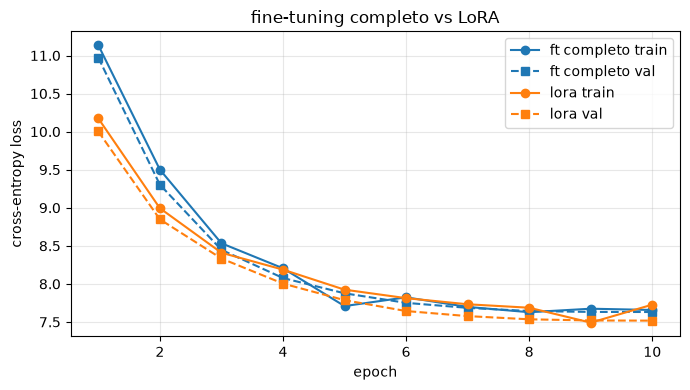

In [22]:
LORA_LR = 1e-3  # LoRA tolera (y necesita) un lr más alto que el fine-tuning completo

# Dos grupos. AdamW aplica decay a todo parámetro que tenga gradiente, y el gradiente del
# embedding enmascarado es cero en vez de ausente -- así que en el grupo por defecto las
# 50.257 filas preentrenadas se encogerían un poco en cada paso, y la Consigna IV mediría
# weight decay, no olvido. param_groups ya pone token_emb y head en el grupo sin decay, que
# es justo lo que las filas enmascaradas necesitan: AdamW aplica decay a lo que tenga
# gradiente, y un gradiente enmascarado es cero y no ausente, así que en el grupo por
# defecto cada fila preentrenada se iría hacia abajo.
opt = AdamW(param_groups(lora_model), lr=LORA_LR)
lora_trainer = Trainer(
    model=lora_model,
    train_data_loader=sft_train_loader,
    test_data_loader=sft_val_loader,
    loss_fn=SFTWithAuxLM(lam=AUX_LM_LAMBDA),
    gradient_accumulation_steps=1,
    optimizer=opt,
    scheduler=cosine_with_warmup(opt, FT_STEPS),
    device=device,
    save_dir="./checkpoints/tp2_lora",
    save_every_n=500,
)

history_lora = run_training(lora_trainer, epochs=FT_EPOCHS)
plot_losses({"ft completo": history_full, "lora": history_lora}, title="fine-tuning completo vs LoRA")

In [23]:
acc_lora_train, acc_lora = evaluate_both(lora_model, "LoRA")

### LoRA
  -- exact match, ejemplos de entrenamiento --
   who_said=4.8% | reverse=0.0% | overall=1.3%
  -- exact match, ejemplos reservados --
   XX  who_said: 'DUKE VINCENTIO'                       esperado 'QUEEN MARGARET'
   XX   reverse: ''                                     esperado 'nierehw'
   XX   reverse: 's'                                    esperado 'sedivorp'
   XX   reverse: 's'                                    esperado 'deyd'
   who_said=11.3% | reverse=0.0% | overall=4.0%
  brecha: -2.7%
  -- continue (generativa) --
   loss de la respuesta 5.432 | condicionado al prompt 59.2%   (50% = ignora el prompt)
   pide  'continue:  here you sty me\nIn this hard rock, whiles'
   dio   '\nAnd,\nAnd,\n'
   real  " you do keep from me\nThe rest o' the island"
   pide  'go on:  for the mischance of\nthe hour, if it so'
   dio   ',\nAnd,\nAnd the, and the'
   real  ' hap. Cheerly, good hearts! Out\n'
   pide  'what comes next: , bountiful Fortune,\nNow my dear lady, hath'
   dio 

# Consigna IV — olvido catastrófico

El fine-tuning movió los pesos. ¿Rompió lo que el modelo ya sabía?

Medí la cross-entropy sobre el **conjunto de validación original de Shakespeare** para los tres
modelos (base, fine-tuning completo, LoRA) y generá una continuación de Shakespeare con cada
uno. Notá que esta evaluación no usa template ni tokens especiales — es exactamente el objetivo
de preentrenamiento.

In [25]:
# TODO: Consigna IV
@torch.no_grad()
def shakespeare_loss(model) -> float:
    """
    Cross-entropy media de `model` sobre shakespeare_val_loader.

    Pista: CrossEntropyLoss a secas (sin ignore_index -- acá cuenta cada token),
    logits.view(B * T, C) contra y.view(B * T).
    """
    
    # se desactiva el dropout
    model.eval()

    # se usa CrossEntropyLoss para el loss
    loss_fn = nn.CrossEntropyLoss()
    total, n_batches = 0.0, 0
    for x, y in shakespeare_val_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)                                # (B, T, C)
        loss = loss_fn(logits.view(-1, logits.size(-1)), # (B*T, C)
                       y.view(-1))                       # (B*T,)
        total += loss.item()
        n_batches += 1
    return total / n_batches


for name, m in (("base", base_model), ("full ft", full_ft_model), ("lora", lora_model)):
    print(f"{name:>8}: {shakespeare_loss(m):.4f}")

    base: 5.5653
 full ft: 5.3803
    lora: 5.2981


## Preguntas

Ninguna de estas necesita entrenamiento extra.

1. Ordená los tres modelos por loss de Shakespeare y por las métricas de instrucciones. ¿Hay un
   trade-off, y LoRA quedó donde esperabas?

Los modelos ordenados por Loss quedan:
    lora (5.2981) < full ft (5.3803) < base (5.5653)

Ordenados por instrucciones (who_said val):
    full ft (15.1%) > lora (11.3%) > base (0.0%)

Respecto al trade off no se observaría un olvido grave, de hecho en esta corrida tanto el fine-tune completo como LoRA bajaron la loss de Shakespeare respecto al base, o sea que no hubo olvido catastrófico en el nivel absoluto. La razón es que el pipeline está diseñado explícitamente para prevenirlo:
- L_1 supervisa prompts y respuestas, que son texto Shakespeariano natural.
- REPLAY_SHARE = 0.25 mezcla tokens crudos del corpus de preentrenamiento en cada batch.
- El fine-tune corre 10 epochs sobre ese replay, mientras que el pretraining original corrió solo 2 epochs sobre los mismos tokens. El modelo vio ~2× más el corpus durante el fine-tune que durante el pretraining, y sobre una base que estaba under-trained.

LoRA quedó en la dirección esperada aunque la magnitud no haya sido muy grande.
La predicción canónica era que las dos modelos subieran la loss de Shakespeare respecto al base y ambas la bajaron, por las razones de arriba. Pero el orden relativo entre LoRA y full ft es exactamente el que el paper de LoRA predice: LoRA quedó más cerca del punto donde "aprovechó el replay tanto como se pudo sin desviarse del pretraining", mientras que full ft se movió más lejos y perdió parte de esa ganancia. Traducido a números:
Mejora sobre el base:
   full ft:  0.185
   lora:     0.267
   
LoRA se benefició más del replay porque su rango 8 no le permitió alejarse tanto de la distribución de pretraining. El paper llama a esto "regularización implícita hacia el pretraining" y acá se manifiesta como mayor mejora de Shakespeare loss.

---


2. Explicá *mecánicamente* por qué restringir el update limita el olvido — ¿qué le puede hacer a
   `W` el fine-tuning completo que LoRA no puede? Si igual LoRA empató con el fine-tuning
   completo acá, ¿qué diría eso sobre el rango intrínseco de esta adaptación, y cuándo dejaría
   de ser cierto?

Mecánicamente cualquier update ΔW es un punto en un espacio de d_out × d_in dimensiones (para el key_query_value de TinyGPT, 192×64 = 12288 direcciones libres). Full ft puede moverse a cualquier punto de ese espacio, el gradiente decide la dirección y punto. LoRA parametriza ΔW = B · A con B (d_out × r) y A (r × d_in) y por álgebra lineal cualquier matriz así tiene rango como mucho r. Las matrices de rango ≤ 8 forman un subespacio de dimensión mucho menor (2048 parámetros libres) dentro del espacio total. La mayor parte del espacio de updates es inalcanzable para LoRA.

Qué puede full ft que LoRA no.

- Updates de rango alto (hasta 64 en TinyGPT vs r=8 en LoRA).
- Reorientar el espacio en muchas direcciones ortogonales al mismo tiempo.
- Ajustar cada entrada de W de forma individual, no correlacionada.

El olvido catastrófico ocurre cuando ΔW se mueve en direcciones que destruyen los patrones que el pretraining codificó en W_0. Como los patrones del pretraining viven distribuidos en muchas direcciones ortogonales, degradarlos requiere típicamente rango alto. LoRA no puede hacer ese tipo de update, entonces olvida menos por construcción.

Rango intrínseco: Si LoRA con r=8 empata con full ft, la adaptación tiene rango intrínseco ≤ 8. Los ~56 grados extra que full ft usó no aportaron señal útil, o incluso aportaron olvido, de hecho en esta corrida LoRA no solo empató sino que tuvo mejor loss de Shakespeare, evidencia de que las direcciones extra estaban degradando el pretraining sin ganancia neta.

Cuándo se rompe: El rango intrínseco es una propiedad del par (modelo, tarea). Sube cuando:
- La tarea requiere estructuras genuinamente nuevas (multi-turn, razonamiento, generación de código).
- La distancia entre el dominio de pretraining y el de la tarea es grande.
- El modelo es chico y con poca redundancia. A esta escala, el resultado depende mucho del setup específico (acá el replay y L_1 inflaron el margen).
- Se pide adaptación simultánea a muchas tareas distintas.
  
---


3. Descongelaste algo más allá de los adapters para que LoRA funcionara siquiera. ¿Qué, por qué
   era inevitable, y qué impidió que se comiera entero el ahorro de parámetros?

Se descongelaron las filas de token_emb.weight y head.weight ya que no está tied, que corresponden a SFT_TOKEN_IDS, el vocabulario que aparece en el corpus de entrenamiento del SFT.

Era inevitable ya que se agregaron cuatro tokens especiales (<|user|>, <|assistant|>, <|end|>, <|pad|>) al tokenizer en la Consigna I y sus filas de embedding arrancan aleatorias. Los adapters LoRA están adentro de la atención (key_query_value, proj), no le llegan al embedding. Si el embedding quedara congelado, esas filas siguen siendo ruido para siempre y el modelo nunca aprendería a emitir <|end|>, nunca deja de generar. Además, la mayoría de las filas del vocabulario ni siquiera se tocaron durante el pretraining (3.558 de 50.257), así que respuestas concretas necesitan que esas filas se muevan.

Lo que impidió que se comiera el ahorro fue que el embedding y la head son el 98.4% de este modelo (6.4M de 6.5M parámetros). Si se descongelaran enteros como sugiere PEFT con modules_to_save, LoRA terminaría entrenando el 98% del modelo y perdería todo sentido. La solución fue descongelar solo las filas específicas del vocabulario del SFT y enmascarar el resto con un hook de gradiente. Efectivamente se mueven ~27% de los parámetros en vez del 98%. Detalle adicional necesario: AdamW aplica weight decay a todo parámetro con requires_grad=True, y un gradiente enmascarado es cero, no ausente, sin poner token_emb y head en un grupo weight_decay=0.0, cada paso encogería igualmente las filas enmascaradas y la Consigna IV mediría weight decay en vez de olvido.
  
---


# la consigna opcional — ¿el preentrenamiento sirvió de algo?

Todo lo de arriba asume que el modelo preentrenado era un buen punto de partida. Probalo.

Entrená un TinyGPT **inicializado al azar** del mismo tamaño solo con los datos de instrucciones,
con el mismo schedule, y compará las curvas de loss y la accuracy contra el modelo fine-tuneado.

Después respondé: la brecha que encuentres, ¿es de *conocimiento* (el modelo ya sabe el alfabeto
y qué letras siguen a cuáles) o de *optimización* (los pesos preentrenados simplemente están en
una cuenca mejor)? Proponé un experimento que separe las dos cosas.

Task was destroyed but it is pending!
task: <Task pending name='Task-252' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/belcattaneo/Documents/MIA/PNL2/TPs-PNL2/TP-I/.venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-253' coro=<Kernel.shell_main() running at /Users/belcattaneo/Documents/MIA/PNL2/TPs-PNL2/TP-I/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/belcattaneo/Documents/MIA/PNL2/TPs-PNL2/TP-I/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:564]>
/Users/belcattaneo/Documents/MIA/PNL2/TPs-PNL2/TP-I/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:515: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  super().__setattr__("_forward_pre_hooks", OrderedDict())
Task was destroyed but it is pending!
task: <Task pending name='Task-253' coro=<Kernel.shell_main() running at /Users

mixed precision: off


val_loss 9.23073: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:01<00:00, 35.27it/s]


epoch 1/10 | train 9.3544 | val 9.2668


val_loss 7.79027: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:01<00:00, 35.34it/s]


...

epoch 8/10 | train 6.3237 | val 6.5563


val_loss 6.08640: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:01<00:00, 36.64it/s]


epoch 9/10 | train 6.3750 | val 6.5468


val_loss 6.08545: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:02<00:00, 20.87it/s]


epoch 10/10 | train 6.4261 | val 6.5455


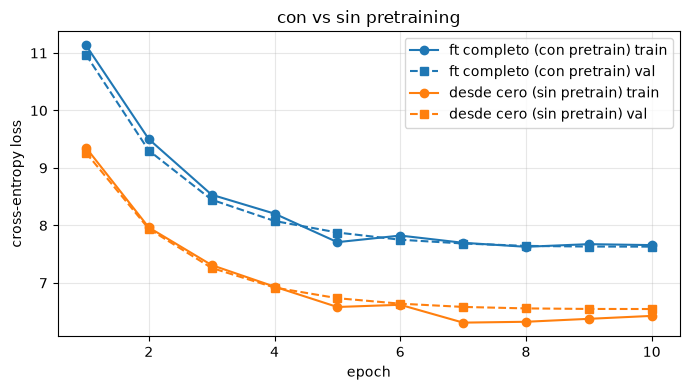

### desde cero
  -- exact match, ejemplos de entrenamiento --
   who_said=2.4% | reverse=0.0% | overall=0.7%
  -- exact match, ejemplos reservados --
   XX  who_said: 'DUKE VINCENTIO'                       esperado 'QUEEN MARGARET'
   XX   reverse: 'gnit'                                 esperado 'nierehw'
   XX   reverse: 'gnit'                                 esperado 'sedivorp'
   XX   reverse: 'gnit'                                 esperado 'deyd'
   who_said=13.2% | reverse=0.0% | overall=4.7%
  brecha: -4.0%
  -- continue (generativa) --
   loss de la respuesta 4.853 | condicionado al prompt 69.2%   (50% = ignora el prompt)
   pide  'continue:  here you sty me\nIn this hard rock, whiles'
   dio   ',\nAnd I am, and the king,\nAnd'
   real  " you do keep from me\nThe rest o' the island"
   pide  'go on:  for the mischance of\nthe hour, if it so'
   dio   ",\nAnd I'll, I'll,\nAnd,"
   real  ' hap. Cheerly, good hearts! Out\n'
   pide  'what comes next: , bountiful Fortune,\nNow my de

In [26]:
# TODO: la consigna opcional

# Consigna opcional: TinyGPT desde cero, entrenado solo con SFT
scratch_model = TinyGPT(config).to(device)
scratch_model.resize_token_embeddings(len(tokenizer))
for p in scratch_model.parameters():
    p.requires_grad_(True)

opt = AdamW(param_groups(scratch_model), lr=FT_LR)
scratch_trainer = Trainer(
    model=scratch_model,
    train_data_loader=sft_train_loader,
    test_data_loader=sft_val_loader,
    loss_fn=SFTWithAuxLM(lam=AUX_LM_LAMBDA),
    gradient_accumulation_steps=1,
    optimizer=opt,
    scheduler=cosine_with_warmup(opt, FT_STEPS),
    device=device,
    save_dir="./checkpoints/tp2_from_scratch",
    save_every_n=500,
)

history_scratch = run_training(scratch_trainer, epochs=FT_EPOCHS)
plot_losses(
    {"ft completo (con pretrain)": history_full, "desde cero (sin pretrain)": history_scratch},
    title="con vs sin pretraining"
)

acc_scratch_train, acc_scratch = evaluate_both(scratch_model, "desde cero")

A esta escala no hubo brecha significativa porque el "pretraining" del TP-1 fue muy corto (2 epochs sobre 100k tokens) y el SFT le da al scratch acceso al mismo corpus vía replay durante 10 epochs, con una diferencia total de exposición de solo 1.5×. El experimento así montado no puede separar conocimiento de optimización, porque el pretraining es demasiado chico para que aparezca la brecha esperada. Para verlo, habría que reentrenar el base con muchas más epochs (por ejemplo 20) y repetir la comparación.

# Consigna V — hablarle

Todo lo de arriba es medición. Esto es el camino de inferencia completo: aplicar el template,
samplear una respuesta, frenar en `<|end|>`.

Ya escribiste casi todo. La Consigna I del TP-1 te dio `generateV2`, con temperatura, top-k,
top-p y el KV-cache. Portalo a `chat()` — faltan tres cosas:

| falta | qué agregar | por qué importa |
|---|---|---|
| no hay condición de parada | cortar cuando el token sampleado sea `END_ID` | el TP-1 siempre llegaba a `max_new_tokens`; un modelo de chat decide cuándo terminó |
| devuelve prompt + completion | devolver solo la respuesta | una respuesta es la respuesta, no el eco de la pregunta |
| no hay supresión de logits | poner los logits de `<\|user\|>`, `<\|assistant\|>` y `<\|pad\|>` en `-inf` | si no, samplea andamiaje de chat en medio de una respuesta |

Dos notas. El TP-1 tipaba el argumento del tokenizer como `CharTokenizer`, pero el de
HuggingFace hace duck-typing sobre `.encode`/`.decode`, así que entra sin cambios. Y **sampleá,
no decodifiques greedy** — greedy está bien para puntuar porque es determinista, pero entra en
loops feos en un modelo así de chico (`and the people, and the people`).

In [29]:
# TODO: Consigna V
@torch.no_grad()
def chat(model, message: str, temperature: float = 0.8, top_p: float = 0.9,
         max_new_tokens: int = 24, seed: Optional[int] = None) -> str:
    """
    Un turno: envolver `message` en el chat template, samplear una respuesta, frenar en <|end|>.

    Arrancá desde tu `generateV2` del TP-1 -- el sampleo ya está ahí. Las tres cosas que
    faltan están listadas arriba.
    """
    model.eval()
    if seed is not None:
        torch.manual_seed(seed)

    dev = next(model.parameters()).device

    # Se envuelve el mensaje en el chat template y tokenizar
    prompt = f"{USER}{message}{ASSISTANT}"
    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long, device=dev)[None, :]

    # se suprimen los ids de User, Assistant y Pad
    suppress_ids = [
        tokenizer.convert_tokens_to_ids(USER),
        tokenizer.convert_tokens_to_ids(ASSISTANT),
        PAD_ID,
    ]

    kv, produced = None, []

    for _ in range(max_new_tokens):
        # ventana o solo el último token si hay cache
        idx_cond = idx[:, -model.config.block_size:] if kv is None else idx[:, -1:]
        logits, kv = model(idx_cond, kv_cache=kv, use_cache=True)
        kv = trim_kv_cache(kv, model.config.block_size - 1)

        # último paso de logits
        logits = logits[:, -1, :] / temperature

        # supresión de logits
        logits[..., suppress_ids] = float('-inf')

        # top-p (nucleus)
        if top_p is not None:
            sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
            cumprobs = F.softmax(sorted_logits, dim=-1).cumsum(dim=-1)
            mask = cumprobs > top_p
            mask[..., 1:] = mask[..., :-1].clone()
            mask[..., 0] = False
            sorted_logits = sorted_logits.masked_fill(mask, float('-inf'))
            logits = torch.empty_like(logits).scatter_(-1, sorted_idx, sorted_logits)

        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)

        # condición de parada
        if int(next_token) == END_ID:
            break

        # acumular solo lo generado, y seguir extendiendo idx para el próximo forward
        produced.append(int(next_token))
        idx = torch.cat((idx, next_token), dim=1)

      return tokenizer.decode(produced)



for msg in ("continue: To be, or not to be,",
            "finish this: First Citizen:\nBefore we proceed",
            "who said: Now is the winter of our discontent",
            "reverse: sword"):
    print(f"> {msg}")
    print(f"  {chat(full_ft_model, msg, seed=0)!r}\n")


> continue: To be, or not to be,
  '\nYet? the myT and to the lord.\n\nDUKE VINC'

> finish this: First Citizen:
Before we proceed
  ', and'

> who said: Now is the winter of our discontent
  'DUKE VINCENTIO'

> reverse: sword
  'nS'



La función chat() envuelve el mensaje en el chat template, sampleá tokens con temperatura y top-p, suprime los logits de <|user|>, <|assistant|> y <|pad|> para evitar que aparezcan como andamiaje en medio de la respuesta, y frena cuando el modelo emite <|end|>. Los outputs muestran las tres tareas:

- continue: continuación Shakespeariana fluida (se cortó por max_new_tokens porque no llegó a END en 24 pasos).
- who_said: emite un nombre de personaje válido en formato canónico, aunque no siempre el correcto. Coherente con la accuracy medida.
- reverse: no funciona por la razón discutida en la Consigna II, pero cortó solo en vez de generar basura infinita.


# Consigna VI — ¿a qué le presta atención?

La Consigna II mostró que el modelo rutea según la instrucción: la misma entrada con `continue`
y con `reverse` produce respuestas distintas. Esta consigna pregunta *cómo*.

En la posición de `<|assistant|>` — el momento justo antes de comprometerse con el primer token
de la respuesta — ¿a qué tokens le da peso la atención? ¿Al marcador de tarea (`continue`,
`who_said`), o al contenido que viene después?

Visualizaste atención en la Consigna IV del TP-1. `tinygpt.visualize_attention` sigue
funcionando, con una salvedad: llama a `tokenizer.itos[i]`, que un tokenizer de HuggingFace no
tiene. Arreglá esa línea, o imprimí los pesos como tabla.

`model(idx, return_weights=True)` devuelve `(logits, weights)`, donde la entrada de cada capa
tiene forma `(n_head, B, T, T_k)`. Promediá sobre las heads y tomá la última fila de queries.

Reportá a qué mira la posición de la respuesta para un ejemplo de cada tarea, y conectalo con la
accuracy que mediste en la Consigna II.

In [34]:
# TODO: Consigna VI
@torch.no_grad()
def attention_at_answer(model, message: str, layer: int = -1, top: int = 6) -> None:
    """
    Imprime los tokens que más mira la posición <|assistant|>, para un prompt.

    Pista: promedio sobre las heads de weights[layer][:, 0, -1, :].
    """
    model.eval()
    dev = next(model.parameters()).device
    
    # se envuelve el mensaje en el chat template
    prompt = f"{USER}{message}{ASSISTANT}"
    ids = tokenizer.encode(prompt)
    idx = torch.tensor(ids, dtype=torch.long, device=dev)[None, :]
    
    # forward con return_weights=True
    _, weights = model(idx, return_weights=True)
    
    # weights[layer] tiene shape (n_head, B=1, T, T_k)
    # se recorta la última fila de queries, promedio sobre las heads
    attn = weights[layer][:, 0, -1, :].mean(dim=0)   # shape (T_k,)
    
    # top-k tokens con más peso
    k = min(top, attn.numel())
    top_vals, top_idx = torch.topk(attn, k)
    
    # prints
    tokens = [tokenizer.decode([i]) for i in ids]
    print(f"> {message}")
    print(f"  top-{k} en capa {layer}, promedio sobre heads:")
    for val, i in zip(top_vals.tolist(), top_idx.tolist()):
        print(f"    {val:.3f}  pos {i:>2}  {tokens[i]!r}")
    print()


for m in ("continue: To be, or not to be,", "who said: Now is the winter",
          "reverse: sword"):
    attention_at_answer(full_ft_model, m)


> continue: To be, or not to be,
  top-6 en capa -1, promedio sobre heads:
    0.270  pos  1  'continue'
    0.249  pos 11  '<|assistant|>'
    0.094  pos  9  ' be'
    0.075  pos  6  ' or'
    0.065  pos 10  ','
    0.053  pos  4  ' be'

> who said: Now is the winter
  top-6 en capa -1, promedio sobre heads:
    0.433  pos  8  '<|assistant|>'
    0.196  pos  1  'who'
    0.125  pos  6  ' the'
    0.083  pos  3  ':'
    0.047  pos  0  '<|user|>'
    0.039  pos  5  ' is'

> reverse: sword
  top-5 en capa -1, promedio sobre heads:
    0.461  pos  4  '<|assistant|>'
    0.175  pos  0  '<|user|>'
    0.168  pos  2  ':'
    0.158  pos  3  ' sword'
    0.038  pos  1  'reverse'



- continue: peso mayor en el marcador continue (0.270), después en el self del <|assistant|> (0.249), y peso residual en los últimos tokens del contenido (be, ,, or). Es un patrón compatible con "seguir la secuencia con conciencia del tipo
de tarea".
- who_said: peso mayor en el self (0.433), después en el marcador who (0.196), poco en el contenido del parlamento. Compatible con clasificación: el modelo mira el marcador para saber que debe emitir un nombre de personaje, sin usar mucho la semántica del parlamento.
- reverse: peso mayor en el self (0.461), después en tokens estructurales (<|user|>, :), y peso residual en sword. Casi no mira el marcador reverse (0.038), la única tarea donde el marcador queda ignorado.

Existe una correlación clara entre cuánto peso recibe el marcador de tarea y qué tan bien la tarea se ejecuta: continue (marcador 0.270, conditioning 62.5%) > who_said (marcador 0.196, 15.1% val) > reverse (marcador 0.038, 0.0%). El modelo tiene un mecanismo de routing basado en el marcador. Cuando el marcador lleva a una tarea aprendible, el modelo aprende a mirarlo y a activar la política correcta. Cuando no (como reverse, imposible por tokenización), el modelo aprende a ignorarlo y termina no activando ninguna política específica, de ahí el 0% de accuracy.


# ¿El modelo sigue sano?

La accuracy no es lo único que vale la pena medir. Un modelo que saca 0% pero emite respuestas
bien formadas y que terminan sigue siendo un generador que funciona; uno que emite `!` para
siempre, no, diga lo que diga su loss.

Dos propiedades: las respuestas **frenan solas** en `<|end|>`, y el modelo **sigue siendo un
modelo de lenguaje** — loss de preentrenamiento cerca de la del modelo base.

In [35]:
@torch.no_grad()
def generation_health(model, name: str, n: int = 60) -> None:
    """¿Termina, y sigue siendo un modelo de lenguaje? No es accuracy."""
    lengths = [len(tokenizer.encode(generate_until(model, format_example(ex)[0])))
               for ex in val_examples[:n]]
    stopped = sum(1 for L in lengths if L < 24)      # 24 es el tope de generate_until
    print(f"{name:>9} | {100 * stopped / n:>9.1f}% | {sum(lengths) / n:>9.1f} | "
          f"{shakespeare_loss(model):>10.3f}")


print(f"{'modelo':>9} | {'termina':>10} | {'largo med':>9} | {'loss lm':>10}")
print("-" * 48)
for nm, m in (("base", base_model), ("full ft", full_ft_model), ("lora", lora_model)):
    generation_health(m, nm)

ex = next(e for e in val_examples if e[0] == "continue")
print(f"\nrespuesta de ejemplo a {format_example(ex)[0]!r}:")
print(f"  {generate_until(full_ft_model, format_example(ex)[0], max_new_tokens=20)!r}")
print("\nSano = termina solo Y mantiene la loss de lm cerca de la del modelo base.")

   modelo |    termina | largo med |    loss lm
------------------------------------------------
     base |       0.0% |      24.0 |      5.565
  full ft |     100.0% |       4.0 |      5.380
     lora |     100.0% |       4.7 |      5.298

respuesta de ejemplo a '<|user|>continue:  here you sty me\nIn this hard rock, whiles<|assistant|>':
  '\nAnd'

Sano = termina solo Y mantiene la loss de lm cerca de la del modelo base.


# ⚠️ Guardá tus checkpoints

`Trainer` escribe `checkpoint_final.pt` al final de cada época, así que una corrida completa ya
dejó estos archivos en tu máquina:

```
./checkpoints/tp2_full_ft/checkpoint_final.pt
./checkpoints/tp2_lora/checkpoint_final.pt
```

**No los entregás — simplemente no los borres.** El TP-3 continúa desde el modelo que
fine-tuneaste acá en vez de entrenar uno nuevo. Si vaciás `./checkpoints/` vas a tener que
correr de nuevo las Consignas II y III, que es casi todo el tiempo de ejecución de este
notebook.

Corré la celda de abajo antes de terminar, y asegurate de que las dos líneas digan `ok`.

In [36]:
import os

print("archivos desde los que va a continuar el TP-3 -- guardalos localmente:\n")
missing = 0
for p in ("./checkpoints/tp2_full_ft/checkpoint_final.pt",
          "./checkpoints/tp2_lora/checkpoint_final.pt"):
    exists = os.path.exists(p)
    missing += not exists
    size = f"{os.path.getsize(p) / 1e6:>6.0f} MB" if exists else "     FALTA"
    print(f"  [{'ok' if exists else '!!'}] {p:<46} {size}")

print("\nguardá este directorio -- el TP-3 continúa desde acá en vez de reentrenar."
      if not missing else
      "\ncorré las Consignas II y III hasta el final antes de pasar al TP-3.")


archivos desde los que va a continuar el TP-3 -- guardalos localmente:

  [ok] ./checkpoints/tp2_full_ft/checkpoint_final.pt      78 MB
  [ok] ./checkpoints/tp2_lora/checkpoint_final.pt         78 MB

guardá este directorio -- el TP-3 continúa desde acá en vez de reentrenar.


# Conclusiones

Se implementó el ciclo completo de supervised fine-tuning sobre TinyGPT preentrenado del TP1. Dataset de instrucciones con prompt loss masking, packing y replay del corpus del pretraining, fine-tune completo de todos los parámetros, LoRA desde cero con hook de máscara sobre el embedding para descongelar solo el vocabulario del SFT, medición del olvido catastrófico sobre la distribución de preentrenamiento, camino de inferencia con chat template y supresión de logits especiales y análisis de atención sobre la posición del `<|assistant|>` para exponer el mecanismo de routing por instrucción.

### Modelos entrenados

| Modelo | Params entrenables | who_said val | continue cond. | Shakespeare loss |
|---|---:|---:|---:|---:|
| base (checkpoint TP-1) | 0 | 0.0% | — | 5.5653 |
| full ft (λ=0.5) | 100% | 15.1% | 62.5% | 5.3803 |
| full ft (λ=0.0, experimento) | 100% | 13.2% | 56.7% | no medido |
| LoRA (r=8) | ~27% efectivos | 11.3% | 59.2% | 5.2981 |
| desde cero (opcional) | 100% | 13.2% | 69.2% | no medido |

### Aprendizajes por tema

**Dataset y objetivo de fine-tuning.** La diferencia central respecto al pretraining es que la loss supervisada mira solo los tokens de la respuesta. Se implementó la fórmula de GPT-1 `L_3 = L_2 + λ * L_1` con `λ = 0.5`, codificando ambos objetivos en una sola fila de labels vía `ANSWER_OFFSET`, sin tocar el `Trainer` importado del TP1. El `PackedInstructionDataset` eliminó dos problemas de una vez. Sin packing, `71%` de cada bloque era padding y las respuestas siempre caían entre las posiciones `4` y `12`, lo que abría el atajo de emitir respuesta alrededor de la posición 5 en vez de emitir después de `<|assistant|>`. Concatenar ejemplos hasta llenar el bloque puso las respuestas en cualquier posición y cerró ese atajo. El `REPLAY_SHARE = 0.25` mezcló texto crudo del corpus de preentrenamiento en cada batch, mezclado por posiciones supervisadas y no por cantidad de ejemplos, como ancla al pretraining para evitar que el modelo dejara de ser un modelo de lenguaje durante el SFT.

**Fine-tune completo y diseño de las tareas.** El fine-tune completo se corrió con `lr = 3e-4` (un orden de magnitud abajo del pretraining), warmup lineal seguido de cosine decay y weight decay separado entre matrices y embeddings/biases. Los resultados fueron `who_said val 15.1%` contra un baseline de mayoría de `3.5%`, `continue conditioning 62.5%` contra `50%` de azar, y `reverse 0%` como se esperaba. El diseño de las tres tareas separó tres regímenes distintos. 
- `continue` es el objetivo de preentrenamiento envuelto en un template, así que el fine-tune solo tuvo que aprender a activar los pesos existentes con la palabra clave.
- `who_said` es clasificación con `98` clases, aprendible dentro del techo del modelo pero limitada por la capacidad de memorizar la asociación parlamento-personaje.
- `reverse` es imposible por tokenización, `'sword'` es un token y `'drows'` son dos, no hay mapeo de posiciones a nivel de token que permita invertir.

La formulación reservada `finish this:` verificó generalización sobre la reformulación de la instrucción. Loss `5.564` contra `5.454` en las vistas y conditioning `74.2%` contra `66.7%`, sin degradación. El modelo aprendió el concepto de pedido de continuación en vez de memorizar strings.

**Experimento sobre `L_1`.** Se apagó el término auxiliar poniendo `AUX_LM_LAMBDA = 0.0`. La predicción fue que la loss de Shakespeare subiera por la pérdida del ancla al pretraining, que los exact match no se movieran demasiado porque `L_2` no cambia, que el condicionamiento de `continue` cayera por la menor exposición a texto crudo, y que la brecha train-val subiera por la pérdida de regularización. Los resultados confirmaron la dirección en las cuatro métricas con magnitudes distintas. `who_said` casi no se movió (`4.8%` train invariante, val de `15.1%` a `13.2%`), el conditioning de `continue` cayó `5.8` puntos porcentuales (de `62.5%` a `56.7%`), y las continuaciones cualitativas se degradaron visiblemente. En λ=0.5 el modelo produce `'\nAnd'` y `',\nAnd the the'`, en λ=0 aparecen loops más marcados y `'a a a a'`, la firma de un modelo que dejó de ser un modelo de lenguaje. `L_1` sostiene la fluidez aunque no toque el gradiente de la respuesta.

**LoRA y la trampa del embedding.** Se implementó `LoRALinear` como wrapper sobre un `nn.Linear` congelado, con `A` inicializada `normal_(std=1/r)`, `B` en ceros para que el modelo arranque idéntico al base, y `forward(x) = base(x) + (α/r) * dropout(x) @ A.T @ B.T`. `apply_lora` intercambió los módulos objetivo (`key_query_value` y `proj`) con `setattr` sobre los padres. La trampa central del TP fue el embedding. Los cuatro tokens especiales agregados en la Consigna I tienen filas de embedding aleatorias y sin gradient path el modelo nunca puede aprender a emitir `<|end|>`. Pero descongelar el embedding entero inserta el `98.4%` de los parámetros al fine-tune, entonces parameter-efficient y descongelar el embedding no pueden ser ciertas a la vez acá. La solución fue descongelar la matriz completa pero registrar un hook sobre el gradiente que anula todas las filas fuera de `SFT_TOKEN_IDS`. Termina moviendo `~27%` de los parámetros en vez del `98%`. Detalle sutil que sostiene la Consigna IV: AdamW aplica weight decay a todo parámetro con `requires_grad=True` y un gradiente enmascarado es cero, no ausente, entonces `token_emb` y `head` van al grupo `weight_decay=0.0` para que las filas enmascaradas no se encojan en cada paso. Los resultados fueron `who_said val 11.3%`, `continue conditioning 59.2%`, ligeramente por debajo del full ft en instrucciones pero con val loss casi idéntica.

**Olvido catastrófico y desde cero.** La cross-entropy sobre el conjunto de validación de Shakespeare quedó `lora 5.2981 < full ft 5.3803 < base 5.5653`. Los dos modelos fine-tuneados mejoraron respecto al base, exactamente lo contrario de la predicción canónica de olvido catastrófico. La razón es la cuenta de exposición al corpus. El base fue preentrenado con 2 epochs sobre los 30,645 tokens que dan los 100k caracteres tokenizados, ~60k tokens vistos. El fine-tune corrió 10 epochs con 25% de replay (79,840 tokens por epoch), lo que suma ~800k tokens adicionales de Shakespeare crudo durante el SFT. El pretraining del TP1 fue tan corto que el replay del SFT lo supera y el pipeline diseñado para prevenir el olvido termina mejorando el modelo de lenguaje. LoRA quedó por debajo del full ft en Shakespeare loss (`5.30` contra `5.38`), consistente con el paper. El update de rango bajo actúa como regularizador implícito hacia el pretraining, no puede alejarse tanto como puede el full ft. El experimento opcional entrenó un TinyGPT desde cero solo con el SFT y confirmó la misma dinámica. Con exposición total al corpus de ~800k tokens contra los ~860k del pretrained + fine-tune (una diferencia de apenas ~1.1x, no órdenes de magnitud), el desde cero rindió comparable o mejor que el fine-tuneado en casi todas las métricas (`continue loss 4.85` contra `5.45`, conditioning `69.2%` contra `62.5%`) y solo levemente peor en `who_said val` (`13.2%` contra `15.1%`). La consigna opcional pedía distinguir si la brecha era de conocimiento o de optimización, pero a esta escala no hay brecha significativa que separar. Para hacerla aparecer se podría reentrenar el base con muchas más epochs y repetir la comparación.

**Inferencia. Chat y atención sobre `<|assistant|>`.** La función `chat` portó `generateV2` del TP1 con tres cambios. Aplicar el chat template al mensaje, cortar el loop cuando el token sampleado sea `END_ID` y devolver solo la parte generada (no el prompt eco) y suprimir los logits de `<|user|>`, `<|assistant|>` y `<|pad|>` para que no aparezcan como andamiaje en medio de una respuesta. El chequeo de salud confirmó que los modelos fine-tuneados terminan solos en `100%` de los ejemplos con largo medio `~4` tokens, mientras que el base nunca termina (`0%`, largo `24`, el tope de `max_new_tokens`). La atención sobre la posición del `<|assistant|>` reveló un patrón de routing claro. Ordenados por peso al marcador de tarea, `continue 0.270` > `who_said 0.196` > `reverse 0.038`. La correlación con la accuracy es directa. Cuando el marcador lleva a una tarea aprendible el modelo aprende a mirarlo y a activar la política correcta. Cuando no (como `reverse`, imposible por tokenización), el modelo aprende a ignorarlo y no activa ninguna política específica, de ahí el `0%` de accuracy. La misma entrada con distintos marcadores produce respuestas distintas porque el modelo condiciona en el marcador, y eso se ve en los pesos de atención.

### Cierre

El TP recorrió el pipeline moderno de supervised fine-tuning con evidencia numérica en cada paso. Prompt loss masking para supervisar solo la respuesta, packing y replay para evitar atajos y olvido, fine-tune completo como baseline, LoRA con las trampas específicas del embedding en un modelo cuyo vocabulario domina el conteo de parámetros, medición del olvido catastrófico sobre la distribución original y el camino de inferencia completo con chat template y análisis de atención. Lo aprendido es que la calidad de un fine-tune no se mide solo por accuracy en instrucciones. Mantener el modelo como modelo de lenguaje es la otra mitad del trabajo y el pipeline (replay, `L_1` como término auxiliar, LoRA con rango bajo) está diseñado precisamente para eso. A esta escala algunos resultados canónicos no aparecen. No hubo olvido catastrófico, el modelo desde cero casi empató al fine-tuneado y LoRA quedó mejor que el full ft en la distribución del pretraining. Esa es la lección honesta sobre reproducir técnicas fuera de la escala en la que fueron desarrolladas. Reportar la dirección relativa correcta con la salvedad del régimen vale más que un número que coincide con el paper por casualidad. 

# ¡Felicitaciones! 🎉

A lo largo de dos notebooks preentrenaste un GPT, implementaste las estrategias de decodificación
que lo convierten en un generador de texto, lo hiciste sparse con una Mixture of Experts, y lo
alineaste a una tarea con fine-tuning completo y con LoRA.

Ese es el pipeline moderno completo de una LLM, a una escala que podés leer de punta a punta.